In [2]:
# conda vina env
import os
import subprocess
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem import rdFMCS
from rdkit.Chem import rdDistGeom
from rdkit.Chem import rdChemReactions
from rdkit.Chem import rdDetermineBonds
from rdkit.Chem.EnumerateStereoisomers import EnumerateStereoisomers
from openbabel import openbabel as ob
from pymol import cmd

In [23]:
gen_set_3 = [
'O=C1CCC(N2Cc3cc(S(=O)(=O)F)ccc3C2=O)C(=O)N1',
'O=C1CCC(N2Cc3c(cccc3S(=O)(=O)F)C2=O)C(=O)N1',
'O=C1CCC(c2ccc(S(=O)(=O)F)cc2)C(=O)N1',
'Cc1ccc(OC2CCC(=O)NC2=O)cc1S(=O)(=O)F',
'C[C@@H]1CN(c2ccc(S(=O)(=O)F)cc2)C(=O)NC1=O',
'O=C1CCC(Oc2cccc(S(=O)(=O)F)c2)C(=O)N1',
'O=C1CCC(Oc2cccc(OS(=O)(=O)F)c2)C(=O)N1',
'O=C1CCC(N2C(=O)c3cc(S(=O)(=O)F)cc4cccc2c34)C(=O)N1',
'O=C1CCC(N2C(=O)c3cc(OS(=O)(=O)F)cc4cccc2c34)C(=O)N1',
'O=C1CCC(Oc2ccc(S(=O)(=O)F)cn2)C(=O)N1',
'Cn1nc(N2CCC(=O)NC2=O)c2cccc(S(=O)(=O)F)c21',
'CN(c1cccc(S(=O)(=O)F)c1)C1CCC(=O)NC1=O',
'CN(c1cccc(OS(=O)(=O)F)c1)C1CCC(=O)NC1=O',
'Cc1ccc(OC2C[C@H](C)C(=O)NC2=O)cc1OS(=O)(=O)F',
'Cc1cc(OC2CCC(=O)NC2=O)cc(OS(=O)(=O)F)c1',
'COc1cc(OC2CCC(=O)NC2=O)cc(OS(=O)(=O)F)c1',
'COc1cc(OC2CCC(=O)NC2=O)cc(S(=O)(=O)F)c1',
'O=C1CCC(CNc2cccc(S(=O)(=O)F)c2)C(=O)N1',
'O=C1CCN(c2ccc(OS(=O)(=O)F)cc2)C(=O)N1',
'COc1ccc(OC2CCC(=O)NC2=O)cc1S(=O)(=O)F',
'Cc1cc(OC2CCC(=O)NC2=O)cc(S(=O)(=O)F)c1',
'COc1ccc(OC2CCC(=O)NC2=O)cc1OS(=O)(=O)F',
'O=C1CCC(Oc2ccc(OS(=O)(=O)F)cn2)C(=O)N1',
'O=C1CCC(n2c(=O)oc3c(S(=O)(=O)F)cccc32)C(=O)N1',
'Cn1nc(N2CCC(=O)NC2=O)c2cccc(OS(=O)(=O)F)c21',
'O=C1CCC(Nc2ccc(C3CCNCC3)c(OS(=O)(=O)F)c2)C(=O)N1',
'O=C1CCC(c2ccc(C3CCNCC3)c(OS(=O)(=O)F)c2)C(=O)N1',
'O=C1NC(=O)C2(Nc3ccc(S(=O)(=O)F)cc3)CC1C2',
'O=C1NC(=O)C2(c3ccc(S(=O)(=O)F)cc3)CC1C2',
'O=C1CCN(c2ccc(C3CCNCC3)c(OS(=O)(=O)F)c2)C(=O)N1',
'O=C1CCN(c2ccc(N3CCNCC3)c(OS(=O)(=O)F)c2)C(=O)N1',
'O=C1CCC(Oc2ccc(C3CCNCC3)c(S(=O)(=O)F)c2)C(=O)N1',
'O=C1CCC(CNc2cccc(OS(=O)(=O)F)c2)C(=O)N1',
]

33


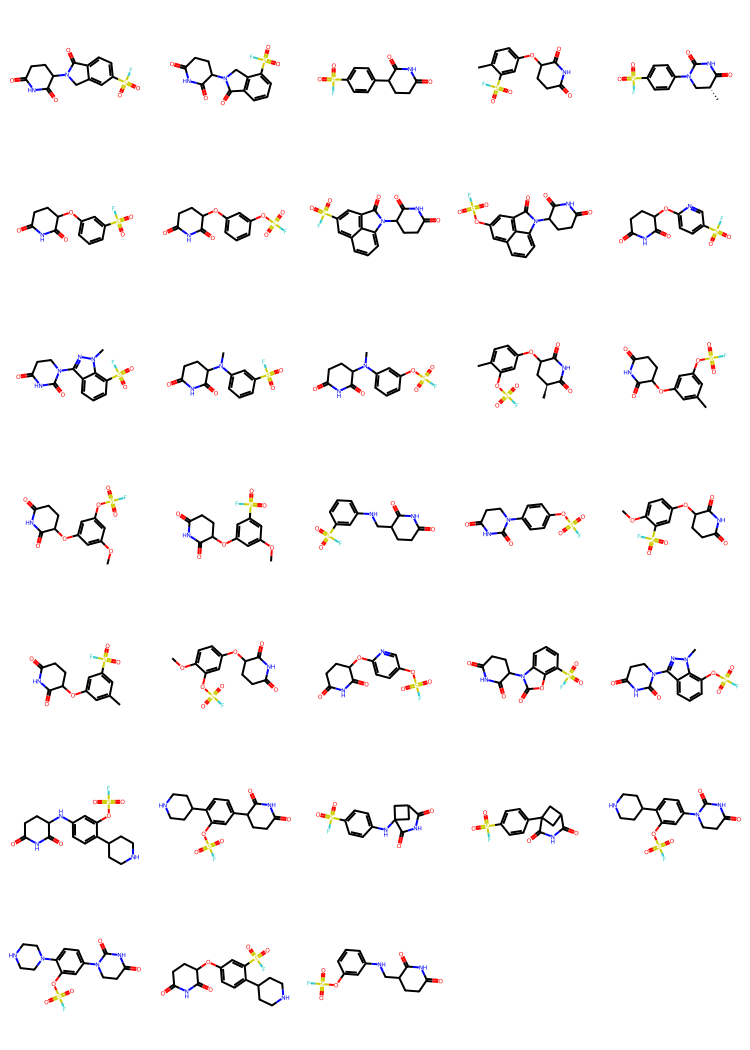

In [24]:
mol_list = []
for smi in gen_set_3:
    mol = Chem.MolFromSmiles(smi)
    Chem.SanitizeMol(mol)
    mol_list.append(mol)
print(len(mol_list))
Draw.MolsToGridImage(mol_list, molsPerRow=5, subImgSize=(150,150))

In [ ]:
def All_Smiles_To_Covalent_Adducts_sdf(smiles_list, saved_conf_count=50, output_folder_path="cov_ligands"):
    ligand_sdf_path_list = []    
    try:
        os.makedirs(output_folder_path, exist_ok=True)
        all_isomers = []
        Histidine_fluorosulf_addition_smarts = (
            "[#9:0]-[#16:1](=[#8:2])(=[#8:3])-[*:4]>>[#6]-[#6]-[#6]1:[#7]:[#6]:[#7](-[#16:1](=[#8:2])(=[#8:3])-[*:4]):[#6]:1"
        )
        rxn_1 = rdChemReactions.ReactionFromSmarts(Histidine_fluorosulf_addition_smarts)
        rxn_2 = None
        rxn_3 = None
    
        for i in smiles_list:
            ligand_nonc = Chem.MolFromSmiles(i)
            Chem.SanitizeMol(ligand_nonc)
            ligand_nonc_isomers = list(EnumerateStereoisomers(ligand_nonc))
            for ii in ligand_nonc_isomers:
                try:
                    ligand_cov = rxn_1.RunReactants((ii,))[0][0]
                    Chem.SanitizeMol(ligand_cov)
                    Chem.AssignStereochemistry(
                        ligand_cov, force=True, flagPossibleStereoCenters=True
                    )
                    ligand_cov_isomers = list(EnumerateStereoisomers(ligand_cov))
                    for iii in ligand_cov_isomers:
                        all_isomers.append(iii)
                    if all_isomers:
                        print(f'molecule smiles {i} prepared for histidine fluorosulf addition successfully')
                    else:
                        raise ValueError(f'histidine fluorosulf addition failed for {i}')
                except:
                    try:
                        ligand_cov = rxn_2.RunReactants((ii,))[0][0]
                        Chem.SanitizeMol(ligand_cov)
                        Chem.AssignStereochemistry(
                            ligand_cov, force=True, flagPossibleStereoCenters=True
                        )
                        ligand_cov_isomers = list(EnumerateStereoisomers(ligand_cov))
                        for iii in ligand_cov_isomers:
                            all_isomers.append(iii)
                        if all_isomers:
                            print('None')
                        else:
                            raise ValueError('None')
    
                    except:
                        ligand_cov = rxn_3.RunReactants((ii,))[0][0]
                        Chem.SanitizeMol(ligand_cov)
                        Chem.AssignStereochemistry(
                            ligand_cov, force=True, flagPossibleStereoCenters=True
                        )
                        ligand_cov_isomers = list(EnumerateStereoisomers(ligand_cov))
                        for iii in ligand_cov_isomers:
                            all_isomers.append(iii)
                        if all_isomers:
                            print('None')
                        else:
                            raise ValueError('None')
                            
        print(f'Total number of isomers generated: {len(all_isomers)}')

        ps = rdDistGeom.ETKDGv3()
        ps.numThreads = 16
        
        for i, isomer in enumerate(all_isomers):
            energy_dict = {}  # conf_id as key; non_conc, energy as values
            Chem.SanitizeMol(isomer)
            isomer_H = Chem.AddHs(isomer)
            AllChem.EmbedMolecule(isomer_H, useRandomCoords=True, maxAttempts=1000)
            AllChem.EmbedMultipleConfs(isomer_H, 1000, ps)
            res = AllChem.MMFFOptimizeMoleculeConfs(isomer_H, maxIters=1000)
    
            for x, y in enumerate(res):
                energy_dict[x] = y
    
            sorted_energy_dict = {
                k: v for k, v in sorted(energy_dict.items(), key=lambda item: item[1][-1])
            }
            #keeping multiple minimised conformers
            pre_conf_id_list = []
            for a, b in sorted_energy_dict.items():
                if b[0] == 0:
                    pre_conf_id = a
                    pre_conf_id_list.append(a)
                    if len(pre_conf_id_list) >= saved_conf_count:
                        break
                    
            ligand_sdf_path = os.path.join(output_folder_path, f"ligand_{i}.sdf")
            ligand_sdf_path_list.append(ligand_sdf_path)
            writer = Chem.SDWriter(ligand_sdf_path)
            isomer_noH= Chem.RemoveAllHs(isomer_H)
            for pre_conf_id in pre_conf_id_list: 
                writer.write(isomer_noH, confId=pre_conf_id)
            writer.close()
        
    except Exception as e:
        print(f"Error occurred: {e}")
        print(f"Returning any existing SDF files in {output_folder_path}")
        if os.path.exists(output_folder_path):
            ligand_sdf_path_list = [os.path.join(output_folder_path, filename) for filename in os.listdir(output_folder_path) if filename.endswith('.sdf')]
        else:
            ligand_sdf_path_list = []

    return ligand_sdf_path_list

All_Smiles_To_Covalent_Adducts_sdf(gen_set_3, saved_conf_count=50, output_folder_path="cov_ligands")

In [ ]:
def split_cocrystal_structure(
    input_pdb_path, output_sdf_path, output_pdb_path
):
    cmd.delete("all")
    cmd.load(input_pdb_path)
    cmd.remove("all and hydro")
    cmd.select("selection_ligand", "org.")
    cmd.extract("LG", "selection_ligand")
    #cmd.h_add("LG")
    cmd.save(output_sdf_path, "LG", format="xyz")
    #cmd.select("selection_metal", "ino.")
    #cmd.remove("selection_metal")
    cmd.save(output_pdb_path, input_pdb_path.split("/")[-1].split(".")[-2])
    cmd.delete("all")

#This optimisse ligand geometry too much, better to use ob
from openbabel import pybel
def convert_xyz_to_sdf(input_path, output_path):
    mol = next(pybel.readfile("xyz", input_path))
    mol.OBMol.ConnectTheDots()
    mol.OBMol.PerceiveBondOrders()
    mol.addh()
    mol.localopt(forcefield="mmff94", steps=500)
    mol.write("sdf", output_path, overwrite=True)
    print(f"Successfully saved {output_path}")
#
for i in ['4TZ4', '5V3O', '8OJH']:
    subprocess.run('mkdir -p '+i, shell=True, check=True)
    split_cocrystal_structure(
        input_pdb_path=f"{i}_binary.pdb",
        output_sdf_path=f"{i}/{i}_ligand.xyz",
        output_pdb_path=f"{i}/{i}_protein.pdb",
    )

In [12]:
def convert_xyz_to_sdf(input_xyz_path, output_sdf_path_noH, output_sdf_path_H):
    obConversion = ob.OBConversion()
    obConversion.SetInAndOutFormats("xyz", "sdf")
    mol = ob.OBMol()
    obConversion.ReadFile(mol, input_xyz_path)
    mol.ConnectTheDots()
    mol.PerceiveBondOrders()
    mol.AddHydrogens()
    obConversion.WriteFile(mol, output_sdf_path_noH)
    cmd.delete("all")
    cmd.load(output_sdf_path_noH)
    cmd.h_add("all")
    cmd.save(output_sdf_path_H)
    cmd.delete("all")

for i in ['4TZ4', '5V3O', '8OJH']:
    convert_xyz_to_sdf(
        input_xyz_path=f"{i}/{i}_ligand.xyz",
        output_sdf_path_noH=f"{i}/{i}_ligand_ob_noH.sdf",
        output_sdf_path_H=f"{i}/{i}_ligand_ob_H.sdf",
    )

In [ ]:
#!obabel -ixyz 4TZ4_ligand.xyz -osdf -O 4TZ4_ligand.sdf 
#!obabel -ixyz 5V3O_ligand.xyz -osdf -O 5V3O_ligand.sdf
#!obabel -ixyz 8OJH_ligand.xyz -osdf -O 8OJH_ligand.sdf

[#6]1(-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])-&!@[#7]1-&@[#6]-&@[#6]2:&@[#6](-&@[#6]-&@1=&!@[#8]):&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@2


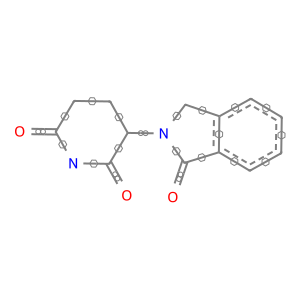

cov_ligands/ligand_0.sdf
Best aligned conformation ID: 38 with MCS RMSD: 0.2895252105828841
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])-&!@[#7]1-&@[#6]-&@[#6]2:&@[#6](-&@[#6]-&@1=&!@[#8]):&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@2


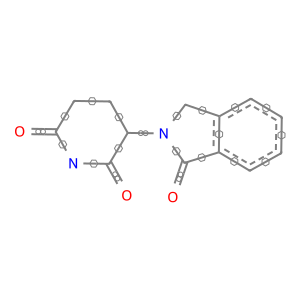

cov_ligands/ligand_1.sdf
Best aligned conformation ID: 37 with MCS RMSD: 1.5427979227104942
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])-&!@[#7]1-&@[#6]-&@[#6]2:&@[#6](-&@[#6]-&@1=&!@[#8]):&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@2


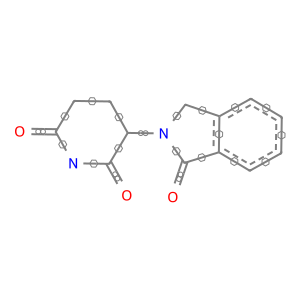

cov_ligands/ligand_2.sdf
Best aligned conformation ID: 42 with MCS RMSD: 0.293029001936207
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])-&!@[#7]1-&@[#6]-&@[#6]2:&@[#6](-&@[#6]-&@1=&!@[#8]):&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@2


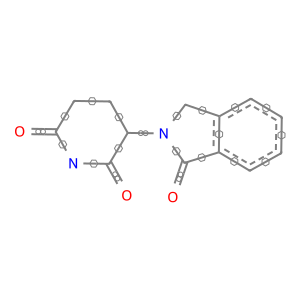

cov_ligands/ligand_3.sdf
Best aligned conformation ID: 30 with MCS RMSD: 1.53706090264197
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


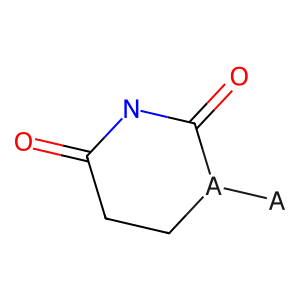

cov_ligands/ligand_4.sdf
Best aligned conformation ID: 19 with MCS RMSD: 0.06140191072257441
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


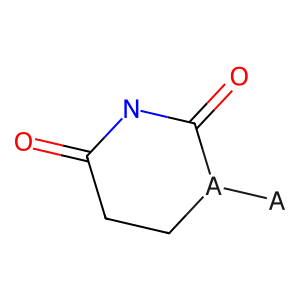

cov_ligands/ligand_5.sdf
Best aligned conformation ID: 32 with MCS RMSD: 0.3796270261133329
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


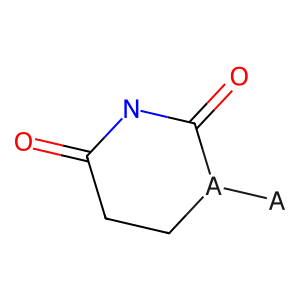

cov_ligands/ligand_6.sdf
Best aligned conformation ID: 35 with MCS RMSD: 0.3885850120098799
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


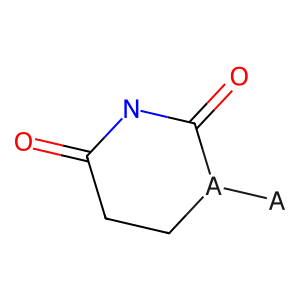

cov_ligands/ligand_7.sdf
Best aligned conformation ID: 36 with MCS RMSD: 0.5861662265004568
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6](:&@[#6]:&@[#6]:&@[#6]:&@1)-&!@[#7]


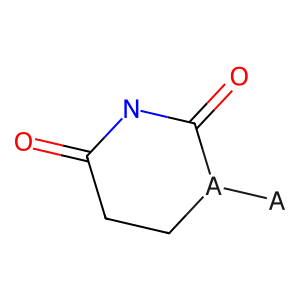

cov_ligands/ligand_8.sdf
Best aligned conformation ID: 13 with MCS RMSD: 0.17875708793870246
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


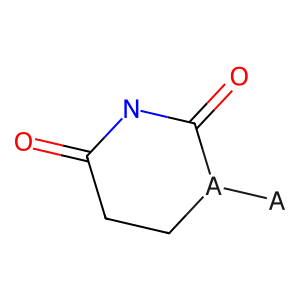

cov_ligands/ligand_9.sdf
Best aligned conformation ID: 47 with MCS RMSD: 0.5928733623346543
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


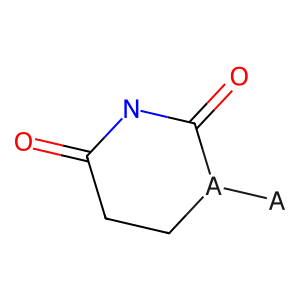

cov_ligands/ligand_10.sdf
Best aligned conformation ID: 31 with MCS RMSD: 0.657965270417434
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


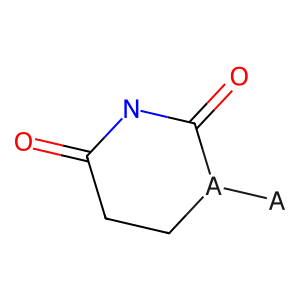

cov_ligands/ligand_11.sdf
Best aligned conformation ID: 7 with MCS RMSD: 0.04861308633993477
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


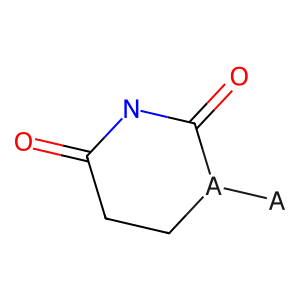

cov_ligands/ligand_12.sdf
Best aligned conformation ID: 8 with MCS RMSD: 0.38394030037237936
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])-&!@[#7]1-&@[#6]-,:;@[#6]2:&@[#6](-&@[#6]-&@1=&!@[#8]):&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@2


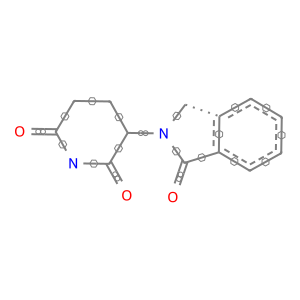

cov_ligands/ligand_13.sdf
Best aligned conformation ID: 10 with MCS RMSD: 1.5287698399302945
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])-&!@[#7]1-&@[#6]-,:;@[#6]2:&@[#6](-&@[#6]-&@1=&!@[#8]):&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@2


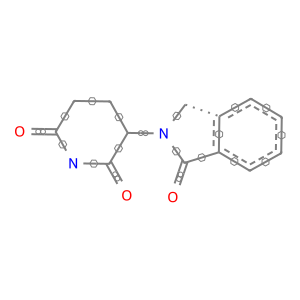

cov_ligands/ligand_14.sdf
Best aligned conformation ID: 30 with MCS RMSD: 0.5832263062506774
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])-&!@[#7]1-&@[#6]-,:;@[#6]2:&@[#6](-&@[#6]-&@1=&!@[#8]):&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@2


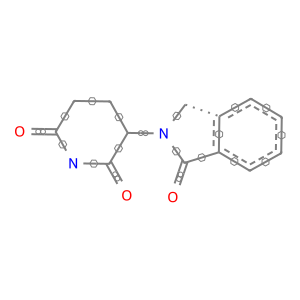

cov_ligands/ligand_15.sdf
Best aligned conformation ID: 1 with MCS RMSD: 1.518203919608863
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])-&!@[#7]1-&@[#6]-,:;@[#6]2:&@[#6](-&@[#6]-&@1=&!@[#8]):&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@2


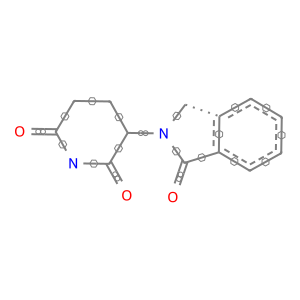

cov_ligands/ligand_16.sdf
Best aligned conformation ID: 48 with MCS RMSD: 0.5835104018615824
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


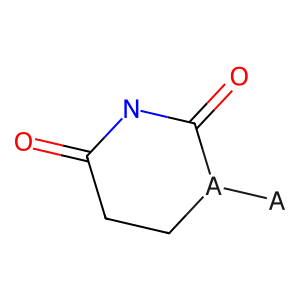

cov_ligands/ligand_17.sdf
Best aligned conformation ID: 1 with MCS RMSD: 0.16865960154889909
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


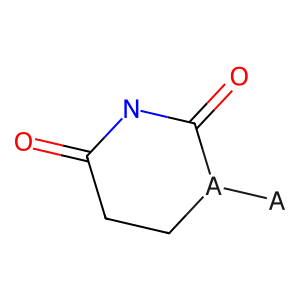

cov_ligands/ligand_18.sdf
Best aligned conformation ID: 2 with MCS RMSD: 0.40534701524127564
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


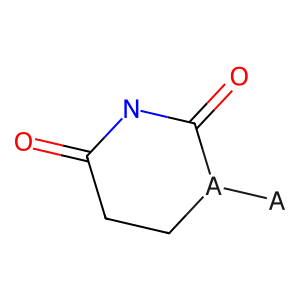

cov_ligands/ligand_19.sdf
Best aligned conformation ID: 21 with MCS RMSD: 0.20916651252938265
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])-&!@[#7]


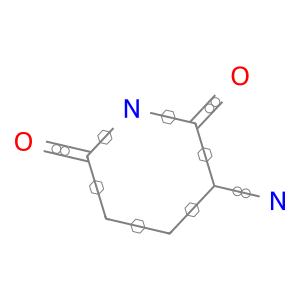

cov_ligands/ligand_20.sdf
Best aligned conformation ID: 42 with MCS RMSD: 0.43711693398307
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])-&!@[#7]


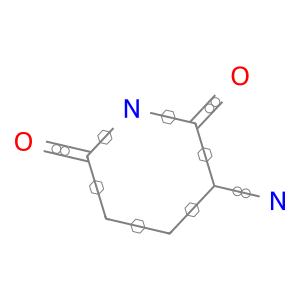

cov_ligands/ligand_21.sdf
Best aligned conformation ID: 27 with MCS RMSD: 0.16797747870339663
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])-&!@[#7]


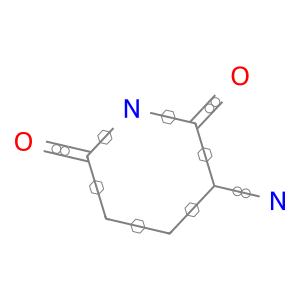

cov_ligands/ligand_22.sdf
Best aligned conformation ID: 49 with MCS RMSD: 0.36710793625989163
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])-&!@[#7]


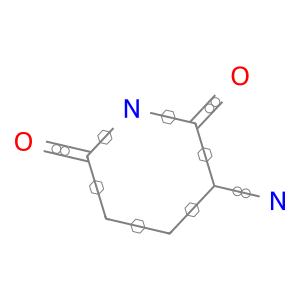

cov_ligands/ligand_23.sdf
Best aligned conformation ID: 7 with MCS RMSD: 0.07673414639948192
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


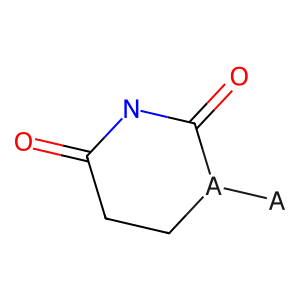

cov_ligands/ligand_24.sdf
Best aligned conformation ID: 28 with MCS RMSD: 0.4145033792136481
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


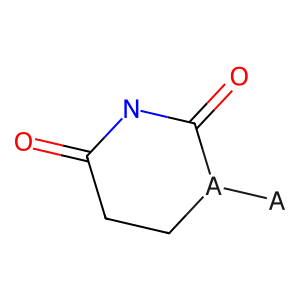

cov_ligands/ligand_25.sdf
Best aligned conformation ID: 38 with MCS RMSD: 0.09747608374307058
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


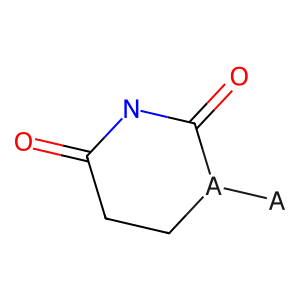

cov_ligands/ligand_26.sdf
Best aligned conformation ID: 14 with MCS RMSD: 0.3839221922765866
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


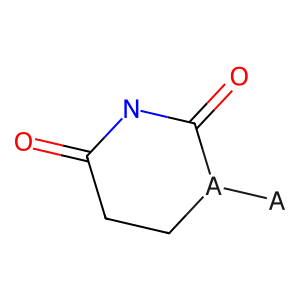

cov_ligands/ligand_27.sdf
Best aligned conformation ID: 8 with MCS RMSD: 0.048447259787335856
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


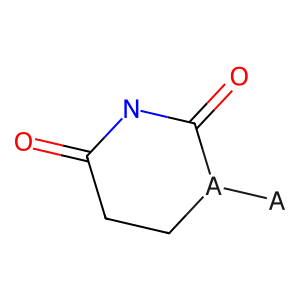

cov_ligands/ligand_28.sdf
Best aligned conformation ID: 11 with MCS RMSD: 0.38368199953875176
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


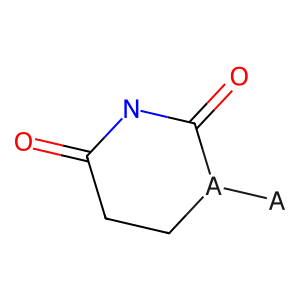

cov_ligands/ligand_29.sdf
Best aligned conformation ID: 9 with MCS RMSD: 0.04790958354832904
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


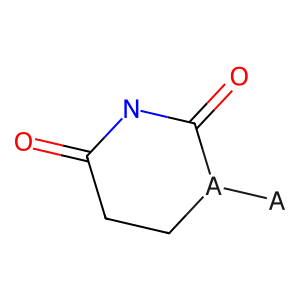

cov_ligands/ligand_30.sdf
Best aligned conformation ID: 46 with MCS RMSD: 0.6556599646322063
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


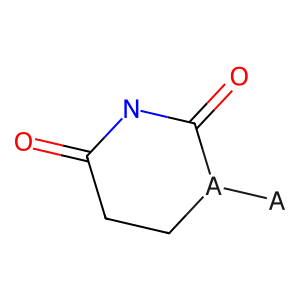

cov_ligands/ligand_31.sdf
Best aligned conformation ID: 46 with MCS RMSD: 0.5910350745299903
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


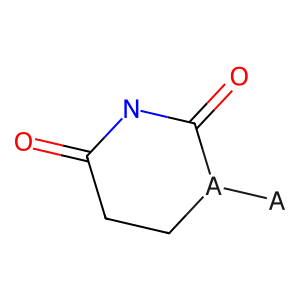

cov_ligands/ligand_32.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.08578940293383074
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


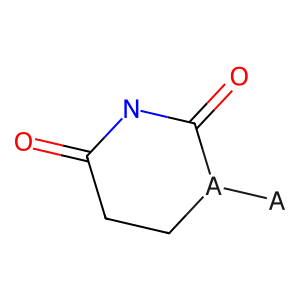

cov_ligands/ligand_33.sdf
Best aligned conformation ID: 3 with MCS RMSD: 0.37392285677474835
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6](:&@[#6]:&@[#6]:&@[#6]:&@1)-&!@[#7]


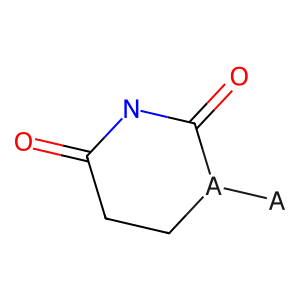

cov_ligands/ligand_34.sdf
Best aligned conformation ID: 2 with MCS RMSD: 0.21497100104555086
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


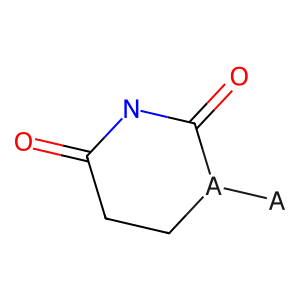

cov_ligands/ligand_35.sdf
Best aligned conformation ID: 5 with MCS RMSD: 0.6625770434558128
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


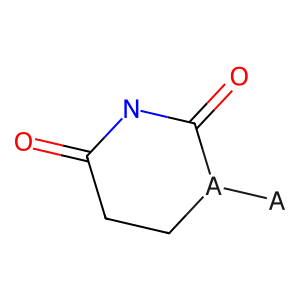

cov_ligands/ligand_36.sdf
Best aligned conformation ID: 22 with MCS RMSD: 0.5978151101657952
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


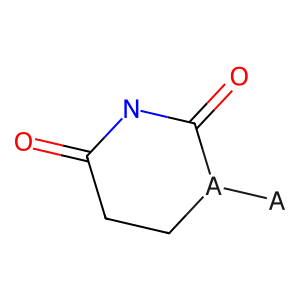

cov_ligands/ligand_37.sdf
Best aligned conformation ID: 21 with MCS RMSD: 0.6583472941818207
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


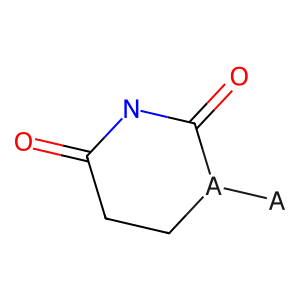

cov_ligands/ligand_38.sdf
Best aligned conformation ID: 33 with MCS RMSD: 0.5932503671387013
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


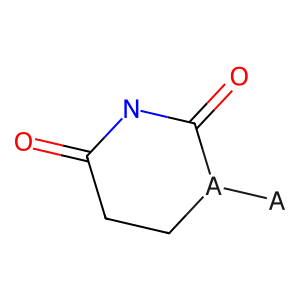

cov_ligands/ligand_39.sdf
Best aligned conformation ID: 43 with MCS RMSD: 0.3956692834797888
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


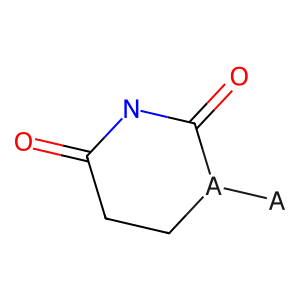

cov_ligands/ligand_40.sdf
Best aligned conformation ID: 29 with MCS RMSD: 0.13151212403610757
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


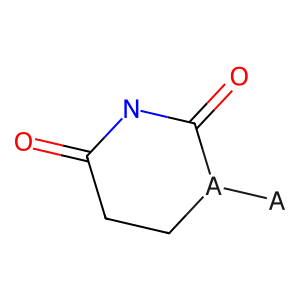

cov_ligands/ligand_41.sdf
Best aligned conformation ID: 18 with MCS RMSD: 0.1793981191969303
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


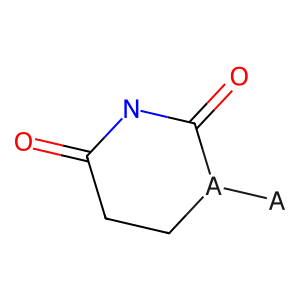

cov_ligands/ligand_42.sdf
Best aligned conformation ID: 5 with MCS RMSD: 0.40925595847882285
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])-&!@[#7]


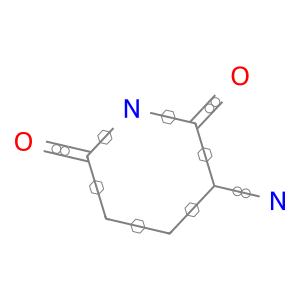

cov_ligands/ligand_43.sdf
Best aligned conformation ID: 14 with MCS RMSD: 0.06471743911194985
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])-&!@[#7]


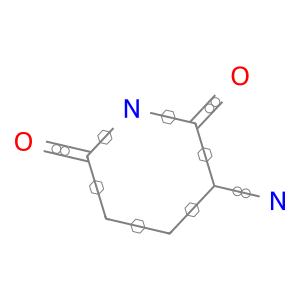

cov_ligands/ligand_44.sdf
Best aligned conformation ID: 42 with MCS RMSD: 0.3702966592950945
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


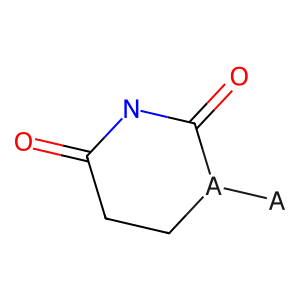

cov_ligands/ligand_45.sdf
Best aligned conformation ID: 16 with MCS RMSD: 0.2083555275821592
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])-&!@[#7]


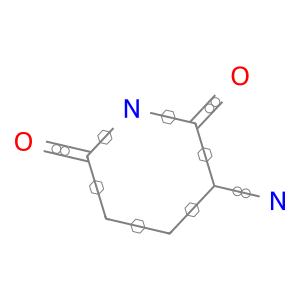

cov_ligands/ligand_46.sdf
Best aligned conformation ID: 41 with MCS RMSD: 0.05983639504008964
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])-&!@[#7]


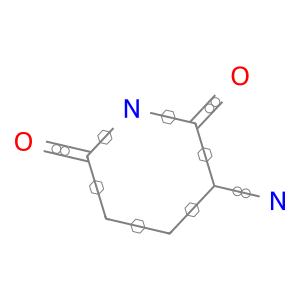

cov_ligands/ligand_47.sdf
Best aligned conformation ID: 44 with MCS RMSD: 0.3883982947732365
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


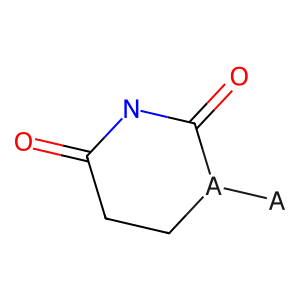

cov_ligands/ligand_48.sdf
Best aligned conformation ID: 3 with MCS RMSD: 0.060195192783119855
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


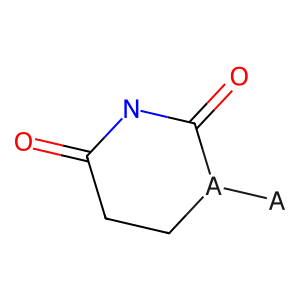

cov_ligands/ligand_49.sdf
Best aligned conformation ID: 4 with MCS RMSD: 0.37533980491234753
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])-&!@[#7]


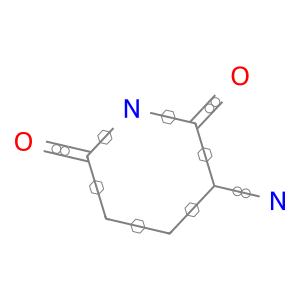

cov_ligands/ligand_50.sdf
Best aligned conformation ID: 12 with MCS RMSD: 0.2875252226148976
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


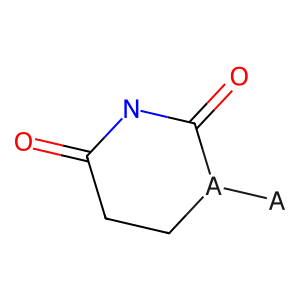

cov_ligands/ligand_51.sdf
Best aligned conformation ID: 11 with MCS RMSD: 0.26891582475512826
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6](:&@[#6]:&@[#6]:&@[#6]:&@1)-&!@[#7]


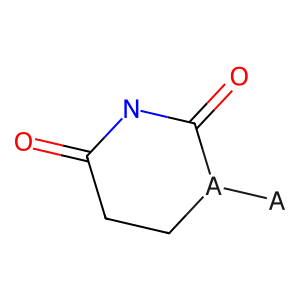

cov_ligands/ligand_52.sdf
Best aligned conformation ID: 27 with MCS RMSD: 0.2065836289797351
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6](:&@[#6]:&@[#6]:&@[#6]:&@1)-&!@[#7]


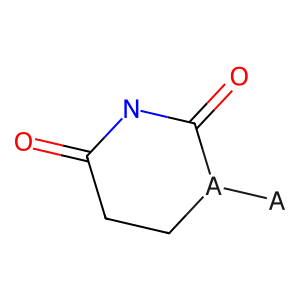

cov_ligands/ligand_53.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.20732184941263715
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


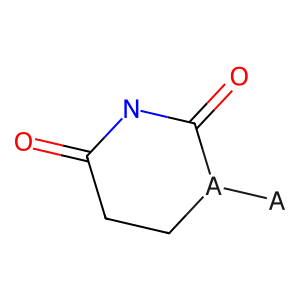

cov_ligands/ligand_54.sdf
Best aligned conformation ID: 15 with MCS RMSD: 0.07120203533033158
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


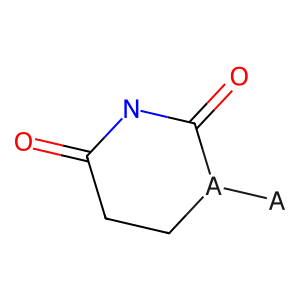

cov_ligands/ligand_55.sdf
Best aligned conformation ID: 44 with MCS RMSD: 0.38696277746138275
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


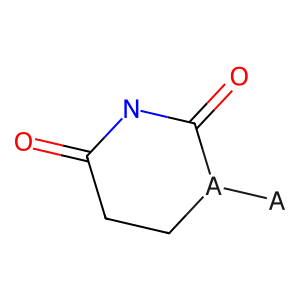

cov_ligands/ligand_56.sdf
Best aligned conformation ID: 1 with MCS RMSD: 0.06555867921339358
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


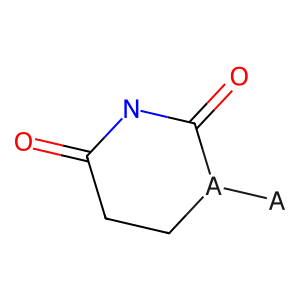

cov_ligands/ligand_57.sdf
Best aligned conformation ID: 9 with MCS RMSD: 0.3805543798023577
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]2:&@[#6]:&@1-&@[#6]-&@[#7](-&@[#6]-&@2=&!@[#8])-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


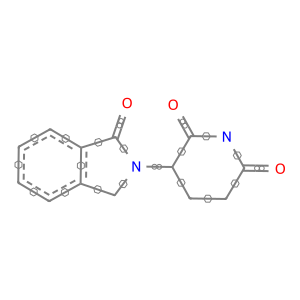

cov_ligands/ligand_0.sdf
Best aligned conformation ID: 38 with MCS RMSD: 0.26635501429448066
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]2:&@[#6]:&@1-&@[#6]-&@[#7](-&@[#6]-&@2=&!@[#8])-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


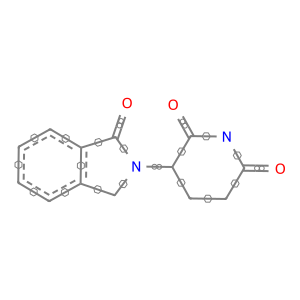

cov_ligands/ligand_1.sdf
Best aligned conformation ID: 37 with MCS RMSD: 1.537530959974749
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]2-&@[#6]-&@[#7](-&@[#6](-&@[#6]:&@2:&@[#6]:&@[#6]:&@1)=&!@[#8])-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


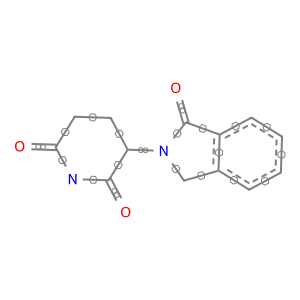

cov_ligands/ligand_2.sdf
Best aligned conformation ID: 42 with MCS RMSD: 0.2686892353166965
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]2-&@[#6]-&@[#7](-&@[#6](-&@[#6]:&@2:&@[#6]:&@[#6]:&@1)=&!@[#8])-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


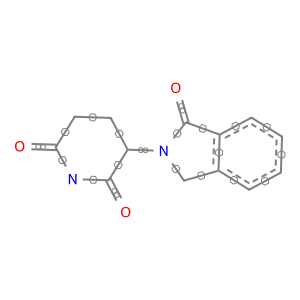

cov_ligands/ligand_3.sdf
Best aligned conformation ID: 30 with MCS RMSD: 1.5319617833737005
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6](=&!@[#8])-&@[#7]-&@[#6](-&@[#6]-&@1)=&!@[#8]


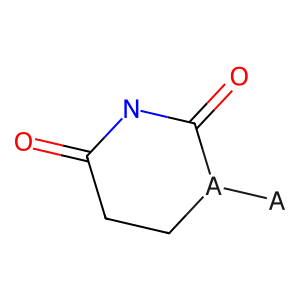

cov_ligands/ligand_4.sdf
Best aligned conformation ID: 19 with MCS RMSD: 0.06677054308141539
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6](=&!@[#8])-&@[#7]-&@[#6](-&@[#6]-&@1)=&!@[#8]


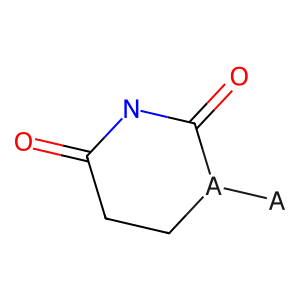

cov_ligands/ligand_5.sdf
Best aligned conformation ID: 32 with MCS RMSD: 0.3832326995369024
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1-&!@[#8]-&!@[#6]


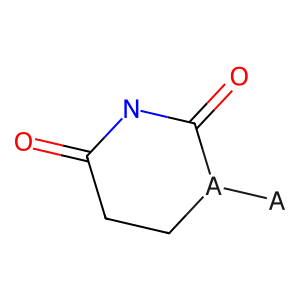

cov_ligands/ligand_6.sdf
Best aligned conformation ID: 35 with MCS RMSD: 0.392395756826831
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1-&!@[#8]-&!@[#6]


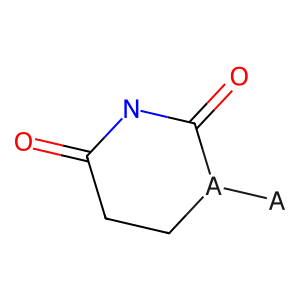

cov_ligands/ligand_7.sdf
Best aligned conformation ID: 36 with MCS RMSD: 0.5854070648631087
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


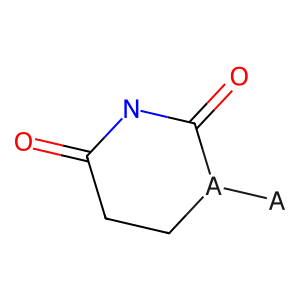

cov_ligands/ligand_8.sdf
Best aligned conformation ID: 13 with MCS RMSD: 0.18461498345225044
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6](:&@[#6]:&@[#6]:&@1)-&!@[#8]-&!@[#6]


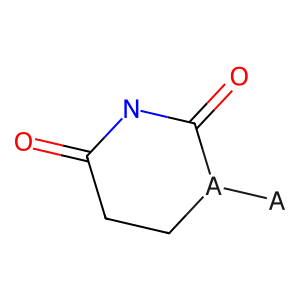

cov_ligands/ligand_9.sdf
Best aligned conformation ID: 47 with MCS RMSD: 0.5921720710600308
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6](:&@[#6]:&@[#6]:&@1)-&!@[#8]-&!@[#6]


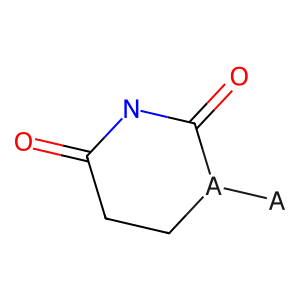

cov_ligands/ligand_10.sdf
Best aligned conformation ID: 31 with MCS RMSD: 0.6626189967792863
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6](:&@[#6]:&@[#6]:&@1)-&!@[#8]-&!@[#6]


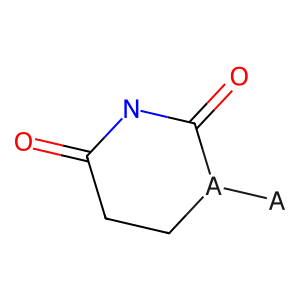

cov_ligands/ligand_11.sdf
Best aligned conformation ID: 7 with MCS RMSD: 0.05092342740391594
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6](:&@[#6]:&@[#6]:&@1)-&!@[#8]-&!@[#6]


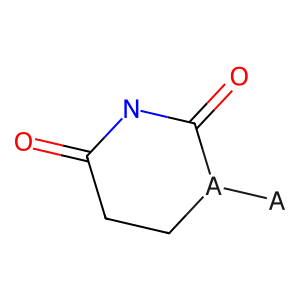

cov_ligands/ligand_12.sdf
Best aligned conformation ID: 8 with MCS RMSD: 0.38771708887535483
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]2:&@[#6]:&@1-&@[#6](-&@[#7](-&@[#6]:,-;@2)-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])=&!@[#8]


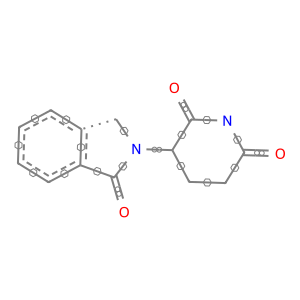

cov_ligands/ligand_13.sdf
Best aligned conformation ID: 10 with MCS RMSD: 1.5432268155484108
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]2:&@[#6]:&@1-&@[#6](-&@[#7](-&@[#6]:,-;@2)-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])=&!@[#8]


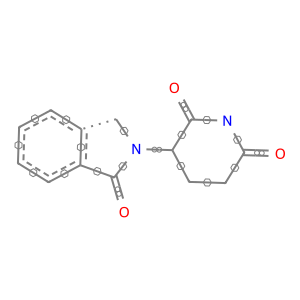

cov_ligands/ligand_14.sdf
Best aligned conformation ID: 30 with MCS RMSD: 0.6073960461201972
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]2:&@[#6]:&@1-&@[#6](-&@[#7](-&@[#6]:,-;@2)-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])=&!@[#8]


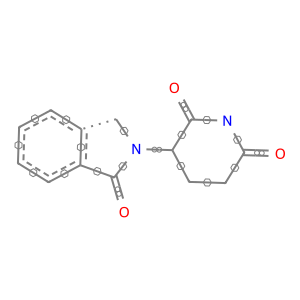

cov_ligands/ligand_15.sdf
Best aligned conformation ID: 1 with MCS RMSD: 1.5319479322320175
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]2:&@[#6]:&@1-&@[#6](-&@[#7](-&@[#6]:,-;@2)-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])=&!@[#8]


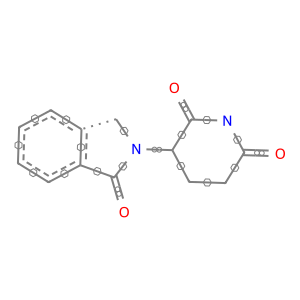

cov_ligands/ligand_16.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.6072353388364885
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6](=&!@[#8])-&@[#7]-&@[#6](-&@[#6]-&@1)=&!@[#8]


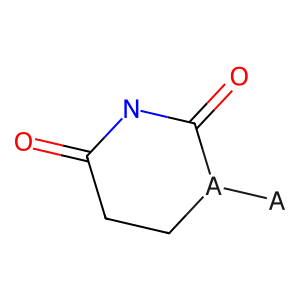

cov_ligands/ligand_17.sdf
Best aligned conformation ID: 1 with MCS RMSD: 0.16829665092133111
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6](=&!@[#8])-&@[#7]-&@[#6](-&@[#6]-&@1)=&!@[#8]


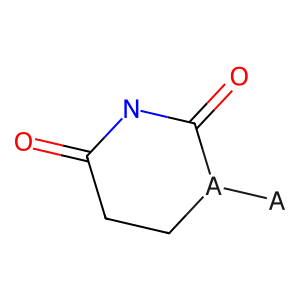

cov_ligands/ligand_18.sdf
Best aligned conformation ID: 2 with MCS RMSD: 0.408826574945569
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


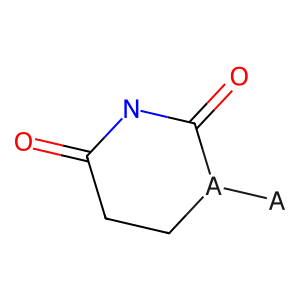

cov_ligands/ligand_19.sdf
Best aligned conformation ID: 21 with MCS RMSD: 0.21444556472547263
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&!@[#7])-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


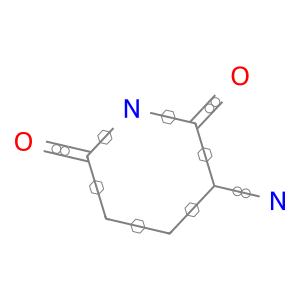

cov_ligands/ligand_20.sdf
Best aligned conformation ID: 42 with MCS RMSD: 0.4400276572468003
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&!@[#7])-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


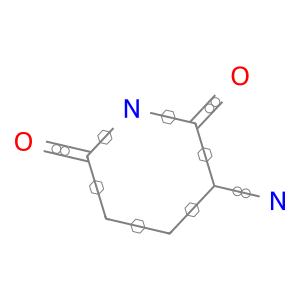

cov_ligands/ligand_21.sdf
Best aligned conformation ID: 27 with MCS RMSD: 0.16898194399459038
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&!@[#7])-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


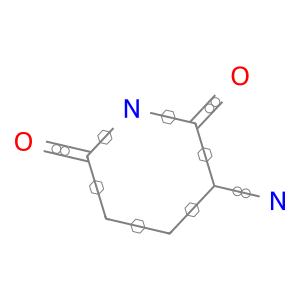

cov_ligands/ligand_22.sdf
Best aligned conformation ID: 49 with MCS RMSD: 0.37075766310881914
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&!@[#7])-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


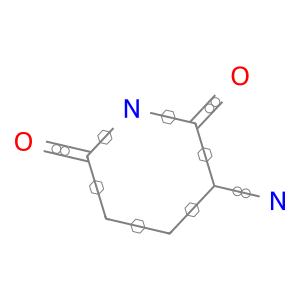

cov_ligands/ligand_23.sdf
Best aligned conformation ID: 10 with MCS RMSD: 0.08350156327862016
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1-&!@[#8]-&!@[#6]


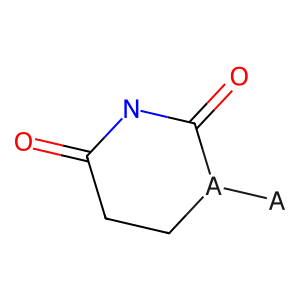

cov_ligands/ligand_24.sdf
Best aligned conformation ID: 28 with MCS RMSD: 0.41808689256709625
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1-&!@[#8]-&!@[#6]


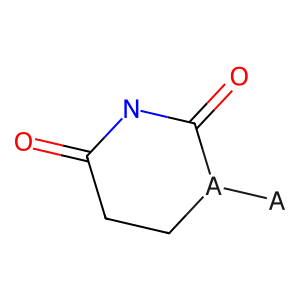

cov_ligands/ligand_25.sdf
Best aligned conformation ID: 38 with MCS RMSD: 0.09576680627748406
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1-&!@[#8]-&!@[#6]


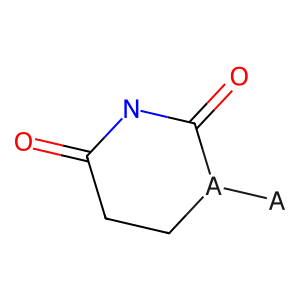

cov_ligands/ligand_26.sdf
Best aligned conformation ID: 14 with MCS RMSD: 0.38768924035460894
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1-&!@[#8]-&!@[#6]


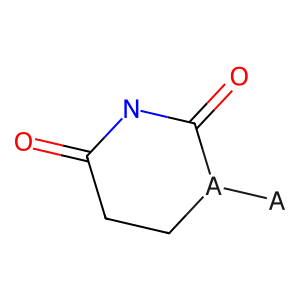

cov_ligands/ligand_27.sdf
Best aligned conformation ID: 8 with MCS RMSD: 0.05066528531907367
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1-&!@[#8]-&!@[#6]


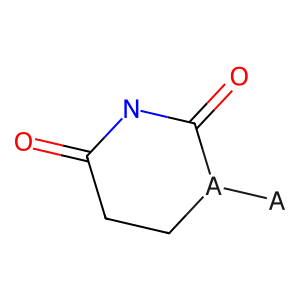

cov_ligands/ligand_28.sdf
Best aligned conformation ID: 11 with MCS RMSD: 0.3874312333804235
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1-&!@[#8]-&!@[#6]


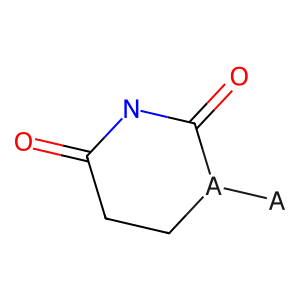

cov_ligands/ligand_29.sdf
Best aligned conformation ID: 6 with MCS RMSD: 0.049859717599670804
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1-&!@[#8]-&!@[#6]


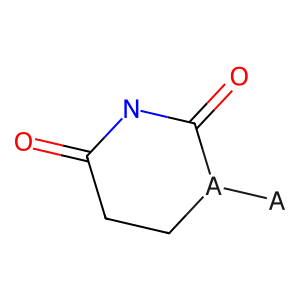

cov_ligands/ligand_30.sdf
Best aligned conformation ID: 46 with MCS RMSD: 0.6603247633706291
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1-&!@[#8]-&!@[#6]


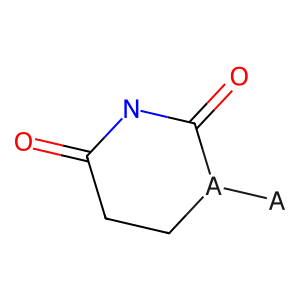

cov_ligands/ligand_31.sdf
Best aligned conformation ID: 46 with MCS RMSD: 0.5903404286126698
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6](=&!@[#8])-&@[#7]-&@[#6](-&@[#6]-&@1)=&!@[#8]


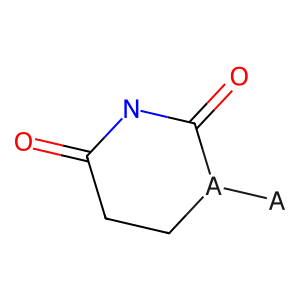

cov_ligands/ligand_32.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.08675847455700281
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6](=&!@[#8])-&@[#7]-&@[#6](-&@[#6]-&@1)=&!@[#8]


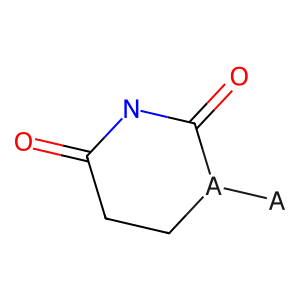

cov_ligands/ligand_33.sdf
Best aligned conformation ID: 3 with MCS RMSD: 0.3766325802998494
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&!@[#8]):&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


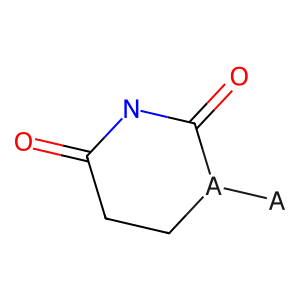

cov_ligands/ligand_34.sdf
Best aligned conformation ID: 2 with MCS RMSD: 0.22053571692589097
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6](-&!@[#8]-&!@[#6]):&@[#6]:&@[#6]:&@[#6]:&@1


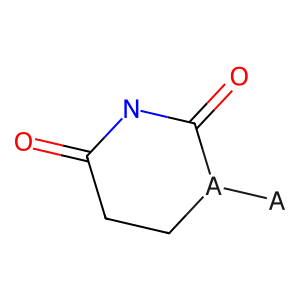

cov_ligands/ligand_35.sdf
Best aligned conformation ID: 5 with MCS RMSD: 0.6670560204991165
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6](-&!@[#8]-&!@[#6]):&@[#6]:&@[#6]:&@[#6]:&@1


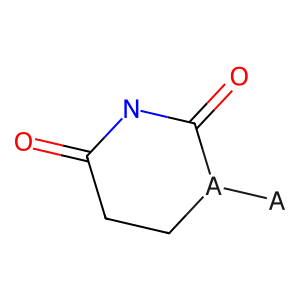

cov_ligands/ligand_36.sdf
Best aligned conformation ID: 22 with MCS RMSD: 0.5970601824486812
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1-&!@[#8]-&!@[#6]


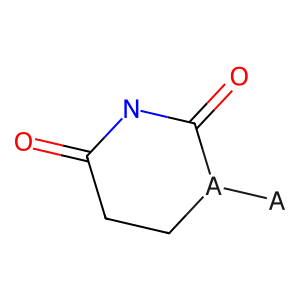

cov_ligands/ligand_37.sdf
Best aligned conformation ID: 21 with MCS RMSD: 0.6629990772025384
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1-&!@[#8]-&!@[#6]


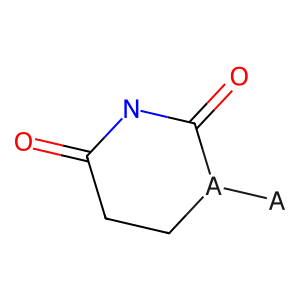

cov_ligands/ligand_38.sdf
Best aligned conformation ID: 33 with MCS RMSD: 0.5925509893331941
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6](-&!@[#8]-&!@[#6]):&@[#6]:&@[#6]:&@[#6]:&@1


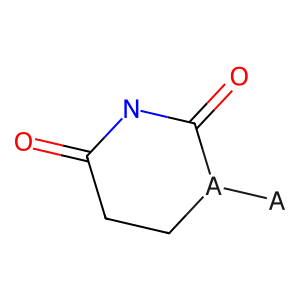

cov_ligands/ligand_39.sdf
Best aligned conformation ID: 43 with MCS RMSD: 0.3995604036591488
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6](-&!@[#8]-&!@[#6]):&@[#6]:&@[#6]:&@[#6]:&@1


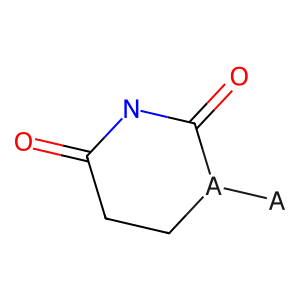

cov_ligands/ligand_40.sdf
Best aligned conformation ID: 29 with MCS RMSD: 0.13258151302852597
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6](=&!@[#8])-&@[#7]-&@[#6](-&@[#6]-&@1)=&!@[#8]


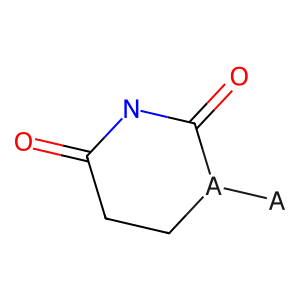

cov_ligands/ligand_41.sdf
Best aligned conformation ID: 18 with MCS RMSD: 0.17872649613259173
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6](=&!@[#8])-&@[#7]-&@[#6](-&@[#6]-&@1)=&!@[#8]


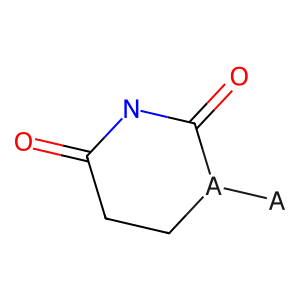

cov_ligands/ligand_42.sdf
Best aligned conformation ID: 5 with MCS RMSD: 0.4126231090258371
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&!@[#7])-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


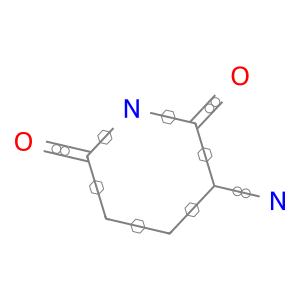

cov_ligands/ligand_43.sdf
Best aligned conformation ID: 14 with MCS RMSD: 0.0667014402325472
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&!@[#7])-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


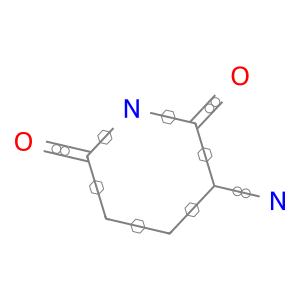

cov_ligands/ligand_44.sdf
Best aligned conformation ID: 42 with MCS RMSD: 0.37285462590535384
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&!@[#8]):&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


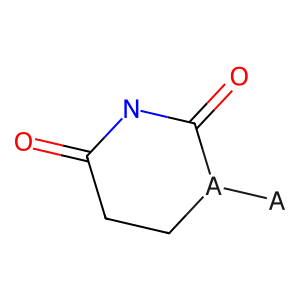

cov_ligands/ligand_45.sdf
Best aligned conformation ID: 16 with MCS RMSD: 0.21361292251709188
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&!@[#7])-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


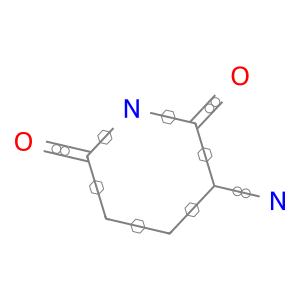

cov_ligands/ligand_46.sdf
Best aligned conformation ID: 41 with MCS RMSD: 0.05780439385712792
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&!@[#7])-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


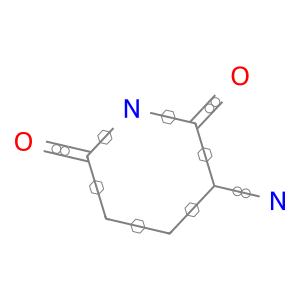

cov_ligands/ligand_47.sdf
Best aligned conformation ID: 44 with MCS RMSD: 0.39148544723908424
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(:&@[#6]:&@[#6]:&@[#6](:&@[#6]:&@[#6]:&@1)-&!@[#6])-&!@[#6]


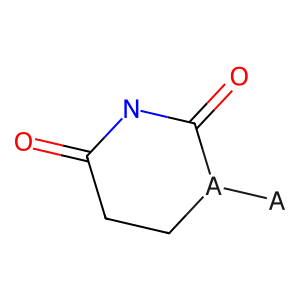

cov_ligands/ligand_48.sdf
Best aligned conformation ID: 3 with MCS RMSD: 0.06571035586790558
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(:&@[#6]:&@[#6]:&@[#6](:&@[#6]:&@[#6]:&@1)-&!@[#6])-&!@[#6]


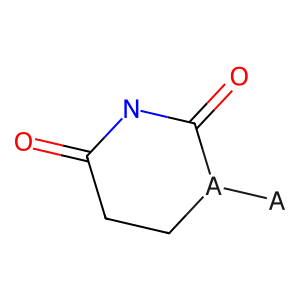

cov_ligands/ligand_49.sdf
Best aligned conformation ID: 4 with MCS RMSD: 0.37893126910703234
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&!@[#7])-&@[#6](-&@[#7]-&@[#6](-&@[#6]-&@[#6]-&@1)=&!@[#8])=&!@[#8]


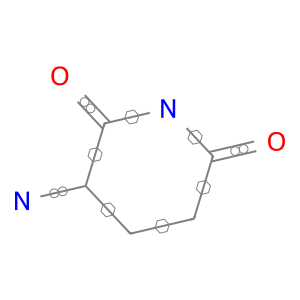

cov_ligands/ligand_50.sdf
Best aligned conformation ID: 12 with MCS RMSD: 0.2931368216177925
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&@[#6]-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@1)=&!@[#8])=&!@[#8]


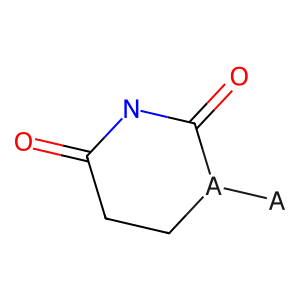

cov_ligands/ligand_51.sdf
Best aligned conformation ID: 11 with MCS RMSD: 0.27359734887633924
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&!@[#8]):&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


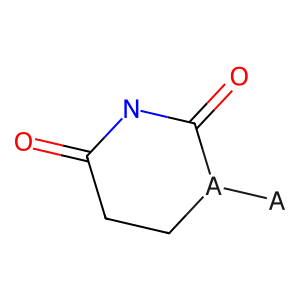

cov_ligands/ligand_52.sdf
Best aligned conformation ID: 27 with MCS RMSD: 0.21211515751358012
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&!@[#8]):&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


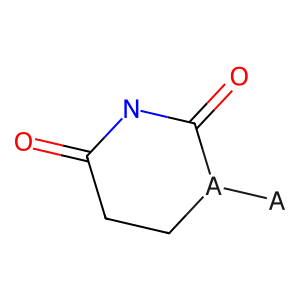

cov_ligands/ligand_53.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.21289385844267858
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6](:&@[#6]:&@[#6]:&@1)-&!@[#8]-&!@[#6]


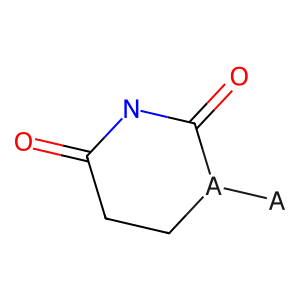

cov_ligands/ligand_54.sdf
Best aligned conformation ID: 15 with MCS RMSD: 0.07306401377235935
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6](:&@[#6]:&@[#6]:&@1)-&!@[#8]-&!@[#6]


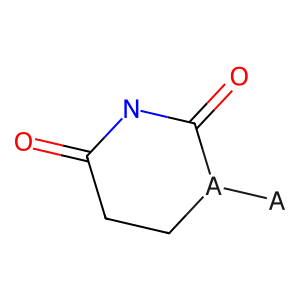

cov_ligands/ligand_55.sdf
Best aligned conformation ID: 44 with MCS RMSD: 0.39085879808416707
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6](=&!@[#8])-&@[#7]-&@[#6](-&@[#6]-&@1)=&!@[#8]


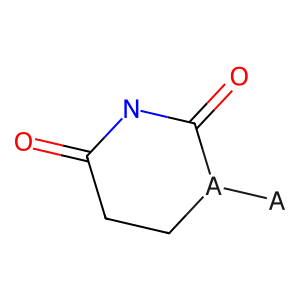

cov_ligands/ligand_56.sdf
Best aligned conformation ID: 1 with MCS RMSD: 0.06727665450467224
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6](=&!@[#8])-&@[#7]-&@[#6](-&@[#6]-&@1)=&!@[#8]


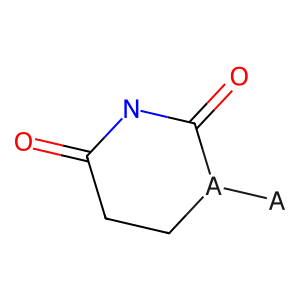

cov_ligands/ligand_57.sdf
Best aligned conformation ID: 9 with MCS RMSD: 0.3834657882529599
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]2:&@[#6](:&@[#6]:&@[#6]:&@[#6]:&@1)-&@[#6]-&@[#7](-&@[#6]-&@2=&!@[#8])-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


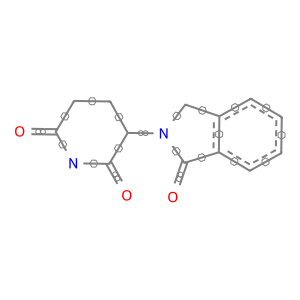

cov_ligands/ligand_0.sdf
Best aligned conformation ID: 38 with MCS RMSD: 0.3696741713611212
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]2:&@[#6](:&@[#6]:&@[#6]:&@[#6]:&@1)-&@[#6]-&@[#7](-&@[#6]-&@2=&!@[#8])-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


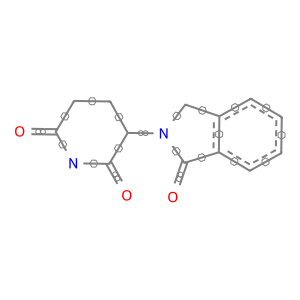

cov_ligands/ligand_1.sdf
Best aligned conformation ID: 38 with MCS RMSD: 1.5228283191372833
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]2:&@[#6](:&@[#6]:&@[#6]:&@[#6]:&@1)-&@[#6]-&@[#7](-&@[#6]-&@2=&!@[#8])-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


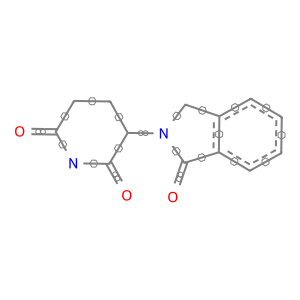

cov_ligands/ligand_2.sdf
Best aligned conformation ID: 42 with MCS RMSD: 0.3715917644204332
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]2:&@[#6](:&@[#6]:&@[#6]:&@[#6]:&@1)-&@[#6]-&@[#7](-&@[#6]-&@2=&!@[#8])-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


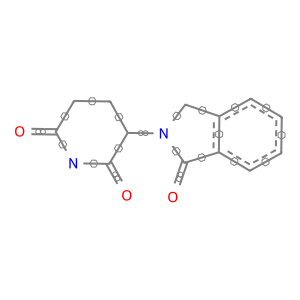

cov_ligands/ligand_3.sdf
Best aligned conformation ID: 30 with MCS RMSD: 1.5153723993659587
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6]-&@[#6]-&@1=&!@[#8]


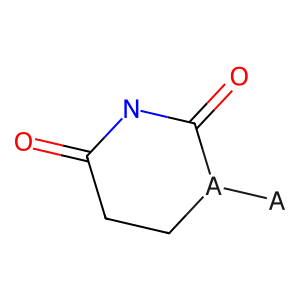

cov_ligands/ligand_4.sdf
Best aligned conformation ID: 6 with MCS RMSD: 0.0904531386974902
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6]-&@[#6]-&@1=&!@[#8]


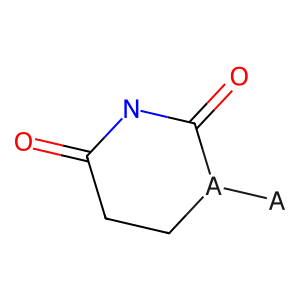

cov_ligands/ligand_5.sdf
Best aligned conformation ID: 33 with MCS RMSD: 0.39180247873960455
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


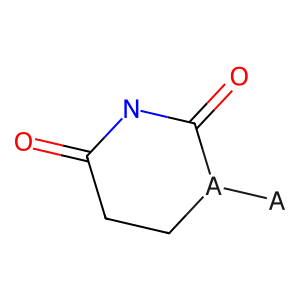

cov_ligands/ligand_6.sdf
Best aligned conformation ID: 35 with MCS RMSD: 0.39908673802452427
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


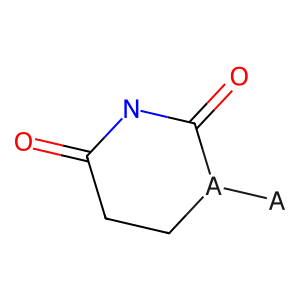

cov_ligands/ligand_7.sdf
Best aligned conformation ID: 36 with MCS RMSD: 0.5467815584780973
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6](:&@[#6]:&@[#6]:&@1)-&!@[#7]


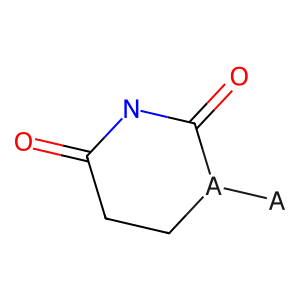

cov_ligands/ligand_8.sdf
Best aligned conformation ID: 19 with MCS RMSD: 0.194233145498904
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


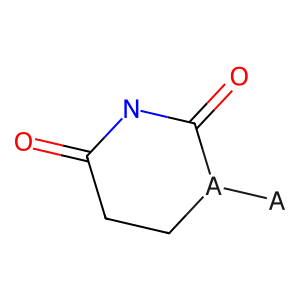

cov_ligands/ligand_9.sdf
Best aligned conformation ID: 47 with MCS RMSD: 0.553039305930345
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


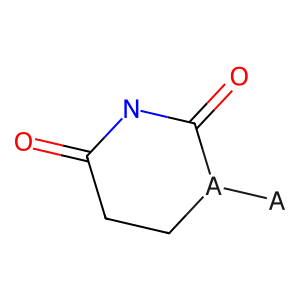

cov_ligands/ligand_10.sdf
Best aligned conformation ID: 31 with MCS RMSD: 0.6816861203757463
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


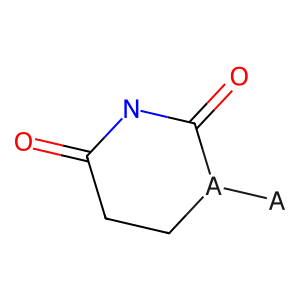

cov_ligands/ligand_11.sdf
Best aligned conformation ID: 24 with MCS RMSD: 0.0466965701361346
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


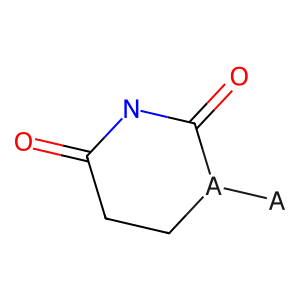

cov_ligands/ligand_12.sdf
Best aligned conformation ID: 25 with MCS RMSD: 0.39085083474365334
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]2:&@[#6](:&@[#6]:&@[#6]:&@[#6]:&@1)-,:;@[#6]-&@[#7](-&@[#6]-&@2=&!@[#8])-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


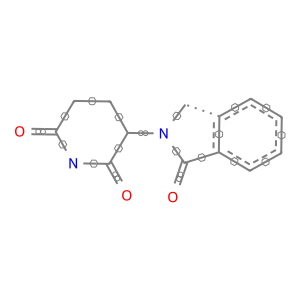

cov_ligands/ligand_13.sdf
Best aligned conformation ID: 10 with MCS RMSD: 1.5146223704020276
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]2:&@[#6](:&@[#6]:&@[#6]:&@[#6]:&@1)-,:;@[#6]-&@[#7](-&@[#6]-&@2=&!@[#8])-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


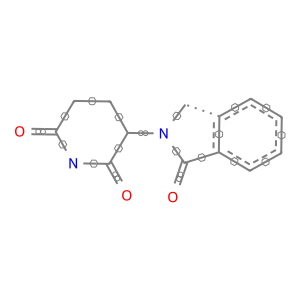

cov_ligands/ligand_14.sdf
Best aligned conformation ID: 30 with MCS RMSD: 0.6858521351140796
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]2:&@[#6](:&@[#6]:&@[#6]:&@[#6]:&@1)-,:;@[#6]-&@[#7](-&@[#6]-&@2=&!@[#8])-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


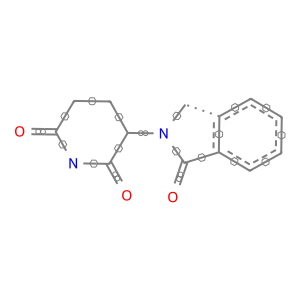

cov_ligands/ligand_15.sdf
Best aligned conformation ID: 1 with MCS RMSD: 1.5016177167921034
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]2:&@[#6](:&@[#6]:&@[#6]:&@[#6]:&@1)-,:;@[#6]-&@[#7](-&@[#6]-&@2=&!@[#8])-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


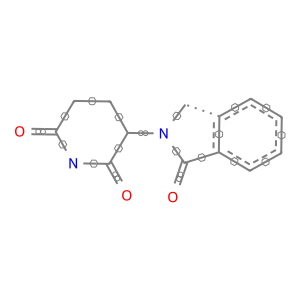

cov_ligands/ligand_16.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.6850987124272873
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6]-&@[#6]-&@1=&!@[#8]


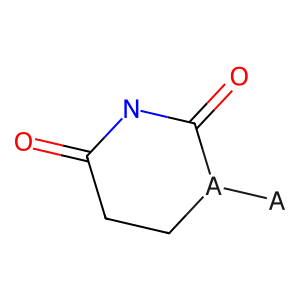

cov_ligands/ligand_17.sdf
Best aligned conformation ID: 1 with MCS RMSD: 0.19263521884886198
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6]-&@[#6]-&@1=&!@[#8]


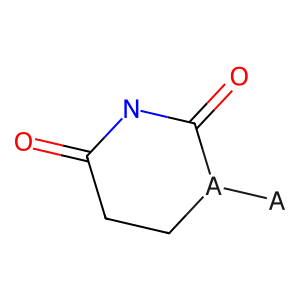

cov_ligands/ligand_18.sdf
Best aligned conformation ID: 2 with MCS RMSD: 0.4079659847988535
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


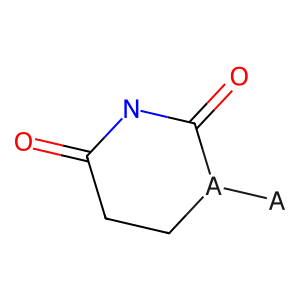

cov_ligands/ligand_19.sdf
Best aligned conformation ID: 21 with MCS RMSD: 0.23272031164548132
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6](-&@[#6]-&@1=&!@[#8])-&!@[#7]


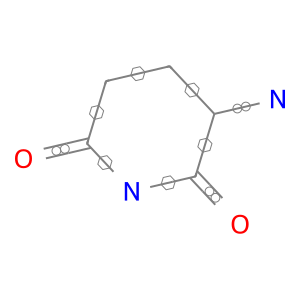

cov_ligands/ligand_20.sdf
Best aligned conformation ID: 42 with MCS RMSD: 0.4544039879098319
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6](-&@[#6]-&@1=&!@[#8])-&!@[#7]


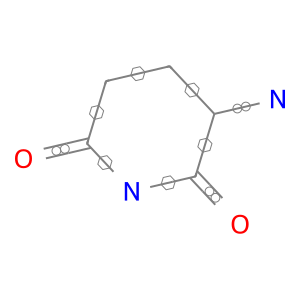

cov_ligands/ligand_21.sdf
Best aligned conformation ID: 24 with MCS RMSD: 0.13043098740459014
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6](-&@[#6]-&@1=&!@[#8])-&!@[#7]


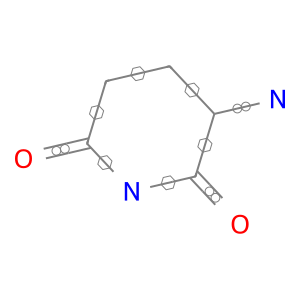

cov_ligands/ligand_22.sdf
Best aligned conformation ID: 49 with MCS RMSD: 0.37255744946641167
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6](-&@[#6]-&@1=&!@[#8])-&!@[#7]


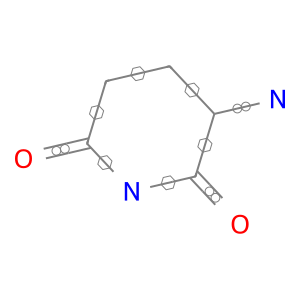

cov_ligands/ligand_23.sdf
Best aligned conformation ID: 3 with MCS RMSD: 0.10213730129430963
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


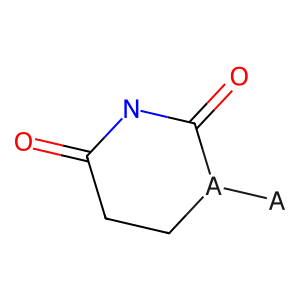

cov_ligands/ligand_24.sdf
Best aligned conformation ID: 28 with MCS RMSD: 0.42469759954243447
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


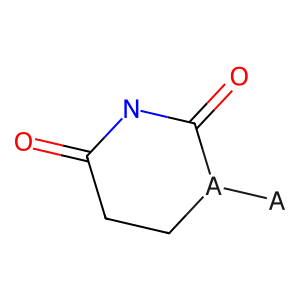

cov_ligands/ligand_25.sdf
Best aligned conformation ID: 38 with MCS RMSD: 0.09185199055680321
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


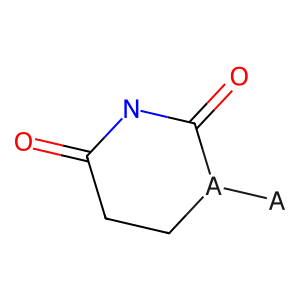

cov_ligands/ligand_26.sdf
Best aligned conformation ID: 20 with MCS RMSD: 0.39089473304326205
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


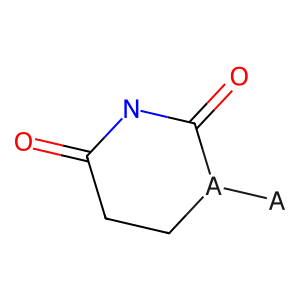

cov_ligands/ligand_27.sdf
Best aligned conformation ID: 36 with MCS RMSD: 0.046036679903985696
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


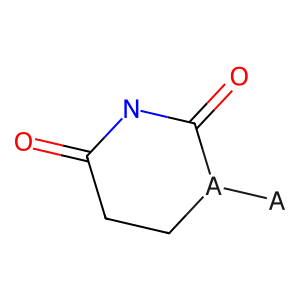

cov_ligands/ligand_28.sdf
Best aligned conformation ID: 23 with MCS RMSD: 0.39073123014963906
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


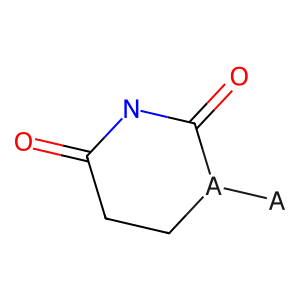

cov_ligands/ligand_29.sdf
Best aligned conformation ID: 33 with MCS RMSD: 0.04749565175807063
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


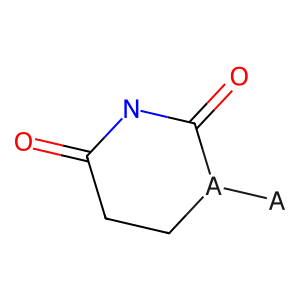

cov_ligands/ligand_30.sdf
Best aligned conformation ID: 46 with MCS RMSD: 0.6793759468273892
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


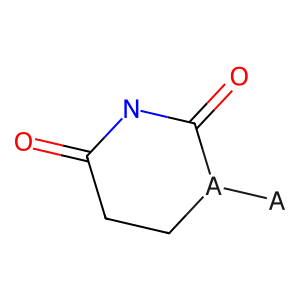

cov_ligands/ligand_31.sdf
Best aligned conformation ID: 46 with MCS RMSD: 0.55129725514116
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6]-&@[#6]-&@1=&!@[#8]


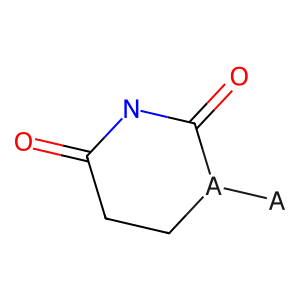

cov_ligands/ligand_32.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.07649330145642151
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6]-&@[#6]-&@1=&!@[#8]


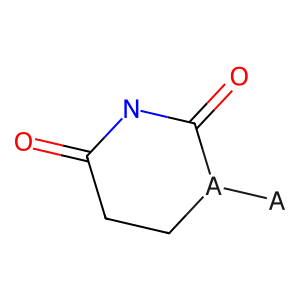

cov_ligands/ligand_33.sdf
Best aligned conformation ID: 3 with MCS RMSD: 0.3785838819754791
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6](:&@[#6]:&@[#6]:&@1)-&!@[#7]


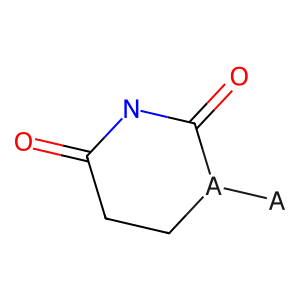

cov_ligands/ligand_34.sdf
Best aligned conformation ID: 2 with MCS RMSD: 0.2340261932747294
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


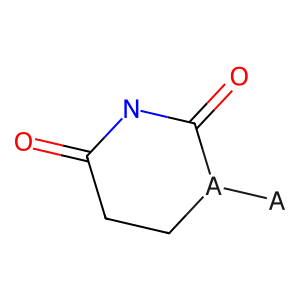

cov_ligands/ligand_35.sdf
Best aligned conformation ID: 18 with MCS RMSD: 0.6859805258126568
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


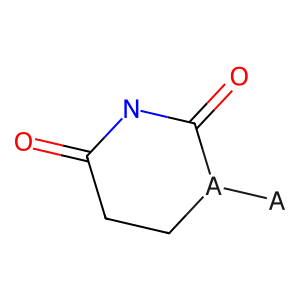

cov_ligands/ligand_36.sdf
Best aligned conformation ID: 22 with MCS RMSD: 0.5575392038501228
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


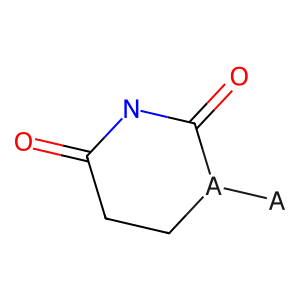

cov_ligands/ligand_37.sdf
Best aligned conformation ID: 21 with MCS RMSD: 0.682067563938199
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


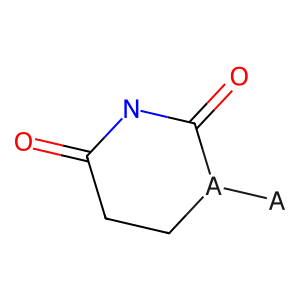

cov_ligands/ligand_38.sdf
Best aligned conformation ID: 33 with MCS RMSD: 0.5534011073644542
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


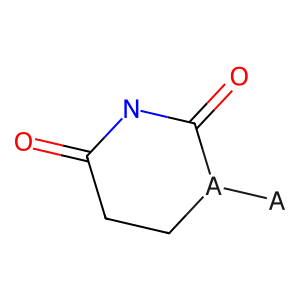

cov_ligands/ligand_39.sdf
Best aligned conformation ID: 43 with MCS RMSD: 0.40126350874813677
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


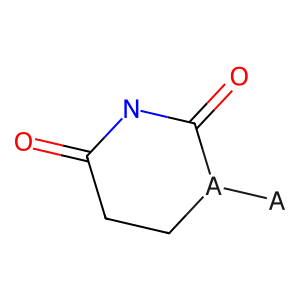

cov_ligands/ligand_40.sdf
Best aligned conformation ID: 29 with MCS RMSD: 0.15641605994467286
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6]-&@[#6]-&@1=&!@[#8]


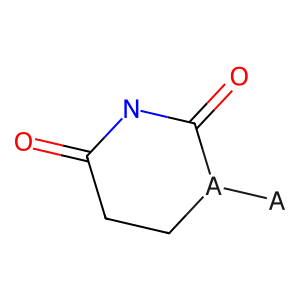

cov_ligands/ligand_41.sdf
Best aligned conformation ID: 18 with MCS RMSD: 0.20275069723998798
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6]-&@[#6]-&@1=&!@[#8]


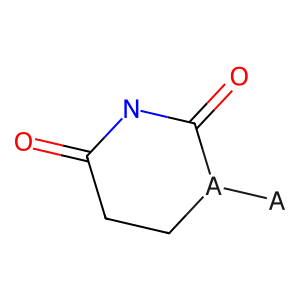

cov_ligands/ligand_42.sdf
Best aligned conformation ID: 5 with MCS RMSD: 0.41114636694084705
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6](-&@[#6]-&@1=&!@[#8])-&!@[#7]


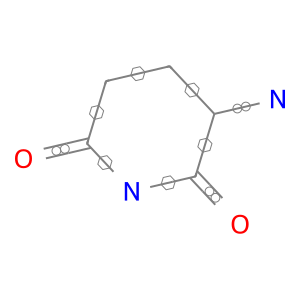

cov_ligands/ligand_43.sdf
Best aligned conformation ID: 14 with MCS RMSD: 0.09219262368759948
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6](-&@[#6]-&@1=&!@[#8])-&!@[#7]


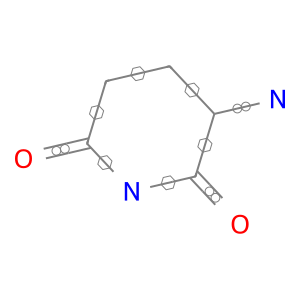

cov_ligands/ligand_44.sdf
Best aligned conformation ID: 42 with MCS RMSD: 0.3797152763044111
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


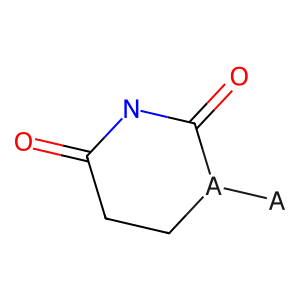

cov_ligands/ligand_45.sdf
Best aligned conformation ID: 16 with MCS RMSD: 0.23209313034623127
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6](-&@[#6]-&@1=&!@[#8])-&!@[#7]


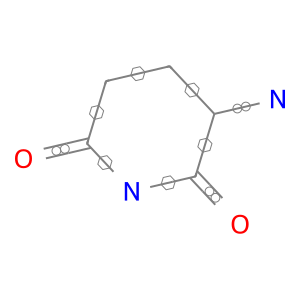

cov_ligands/ligand_46.sdf
Best aligned conformation ID: 41 with MCS RMSD: 0.08883006303242925
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6](-&@[#6]-&@1=&!@[#8])-&!@[#7]


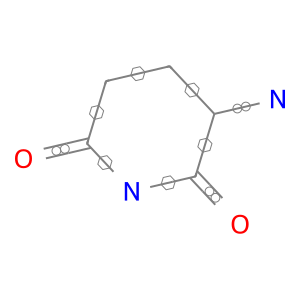

cov_ligands/ligand_47.sdf
Best aligned conformation ID: 44 with MCS RMSD: 0.39756368662805486
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6]-&@[#6]-&@1=&!@[#8]


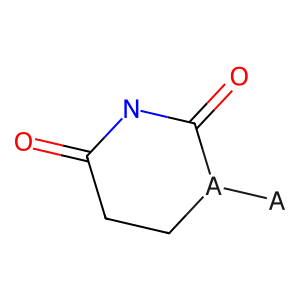

cov_ligands/ligand_48.sdf
Best aligned conformation ID: 5 with MCS RMSD: 0.07334086130945995
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6]-&@[#6]-&@1=&!@[#8]


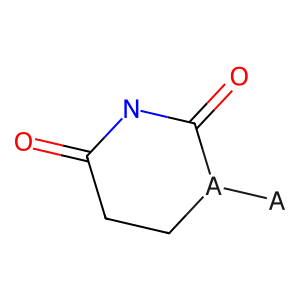

cov_ligands/ligand_49.sdf
Best aligned conformation ID: 4 with MCS RMSD: 0.38636371254574764
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6](-&@[#6]-&@1=&!@[#8])-&!@[#7]


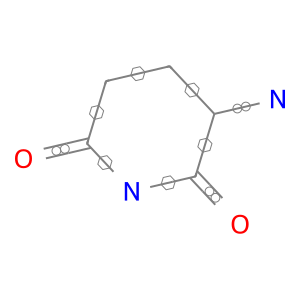

cov_ligands/ligand_50.sdf
Best aligned conformation ID: 43 with MCS RMSD: 0.3202471765565
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6]-&@[#6]-&@1=&!@[#8]


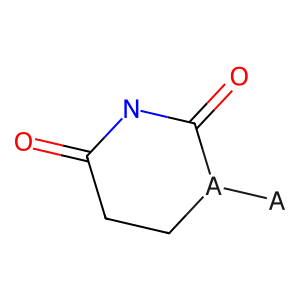

cov_ligands/ligand_51.sdf
Best aligned conformation ID: 31 with MCS RMSD: 0.3058793662388706
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


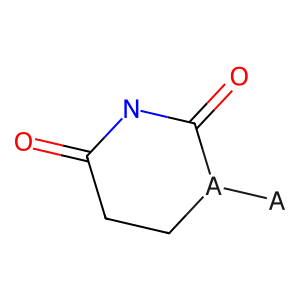

cov_ligands/ligand_52.sdf
Best aligned conformation ID: 3 with MCS RMSD: 0.22562917390310389
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


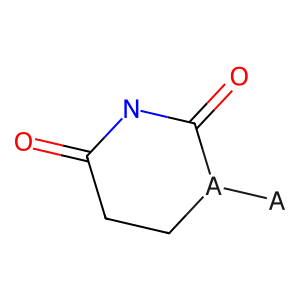

cov_ligands/ligand_53.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.22786585970267662
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


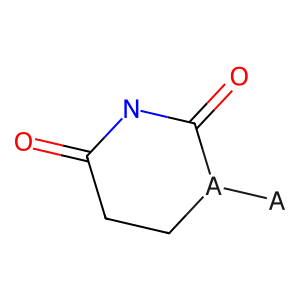

cov_ligands/ligand_54.sdf
Best aligned conformation ID: 15 with MCS RMSD: 0.09604513919690016
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


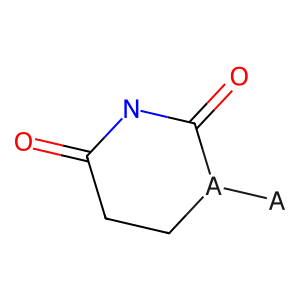

cov_ligands/ligand_55.sdf
Best aligned conformation ID: 44 with MCS RMSD: 0.39537033875003214
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6]-&@[#6]-&@1=&!@[#8]


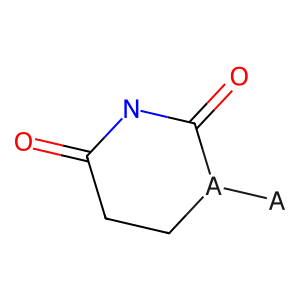

cov_ligands/ligand_56.sdf
Best aligned conformation ID: 1 with MCS RMSD: 0.10325013012596969
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6]-&@[#6]-&@1=&!@[#8]


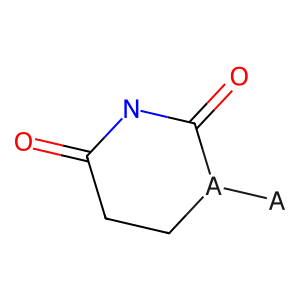

cov_ligands/ligand_57.sdf
Best aligned conformation ID: 9 with MCS RMSD: 0.38913569229567746
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


In [3]:
def get_mcs_rmsd(query_sdf_path, ref_sdf_path, aligned_sdf_path, aligned=True):

    confs = []
    # check the SMILES to verify aromaticity (lowercase atoms like 'c1ccccc1' indicate aromaticity)
    with Chem.SDMolSupplier(query_sdf_path, removeHs=True, sanitize=True) as suppl_query:
        for conf in suppl_query:
            if conf is None: continue
            #print(f"Query SMILES: {Chem.MolToSmiles(conf)}") 
            #display(Draw.MolToImage(conf))
            confs.append(conf)
            
    # Load reference molecule from XYZ file (rdkit suggle with this... so I use sdf converted by obabel)
    #ref_mol = Chem.MolFromXYZFile(ref_xyz_path)
    #display(Draw.MolToImage(ref_mol))
    #rdDetermineBonds.DetermineBondOrders(ref_mol, charge=0)    
    #print(f"Reference SMILES: {Chem.MolToSmiles(ref_mol)}")
    #display(Draw.MolToImage(ref_mol))

    with Chem.SDMolSupplier(ref_sdf_path, removeHs=True, sanitize=True) as suppl_ref:
        ref_mol = suppl_ref[0]
        #print(f"Reference SMILES: {Chem.MolToSmiles(ref_mol)}")
        #display(Draw.MolToImage(ref_mol))
        
    mcs = rdFMCS.FindMCS([confs[0], ref_mol], completeRingsOnly=True, ringMatchesRingOnly=False)
    patt = Chem.MolFromSmarts(mcs.smartsString)
    print(mcs.smartsString)

    #check patt contains imide
    imide_smarts = "[!#1]1(-[#6]-[#6]-[#6](-[#7]-[#6]-1=[#8])=[#8])-[!#1]"
    imide_mol = Chem.MolFromSmarts(imide_smarts)
    if not patt.HasSubstructMatch(imide_mol):
        print("Warning: auto MCS does not contain a cyclic imide group, use defined cyclic imide as MCS instead")
        patt = imide_mol
    display(Draw.MolToImage(patt))
    refMatch = ref_mol.GetSubstructMatch(patt)

    rms_min = None
    best_conf_id = None
    for i, conf in enumerate(confs):
        mv = conf.GetSubstructMatch(patt)
        if aligned == False:
            rms = AllChem.CalcRMS(conf, ref_mol, map=[list(zip(mv, refMatch))])
        else:
            rms = AllChem.AlignMol(conf, ref_mol, atomMap=list(zip(mv, refMatch)))
        if (rms_min is None) or (rms < rms_min):
            rms_min = rms
            best_conf_id = i

    with Chem.SDWriter(aligned_sdf_path) as writer:
        conf_with_hs = Chem.AddHs(confs[best_conf_id], addCoords=True)
        writer.write(conf_with_hs)

    print(query_sdf_path)
    print(f"Best aligned conformation ID: {best_conf_id} with MCS RMSD: {rms_min}")
    print("-"*200)
    return best_conf_id, rms_min

for pdb in ['4TZ4', '5V3O', '8OJH']:
    for i in range(58):
        get_mcs_rmsd(
            query_sdf_path=f"cov_ligands/ligand_{i}.sdf",
            ref_sdf_path=f"{pdb}/{pdb}_ligand_ob_H.sdf",
            aligned_sdf_path=f"cov_ligands/ligand_{i}_mcs_aligned_to_{pdb}.sdf",
        )

In [10]:
#conda openfe env
from sys import stdout
import parmed as pmd
# OpenMM imports
import openmm.app as app
import openmm as mm
import openmm.unit as unit
from openmmforcefields.generators import SMIRNOFFTemplateGenerator
from openmm.app import PDBFile
# OpenFF-toolkit imports
from openff.toolkit import Molecule
from openff.toolkit import Topology as offTopology
from openff.units.openmm import to_openmm as offquantity_to_openmm
#pdbfixer import
from pdbfixer import PDBFixer
#biopython import
from Bio.PDB import PDBParser, PDBIO, Select

In [2]:
def fix_protein_structure(input_pdb_path, output_pdb_path):

    fixer = PDBFixer(filename=input_pdb_path)

    #chains = list(fixer.topology.chains())
    #numChains = len(chains)

    # Keep only the chain crbn
    fixer.removeChains([0])

    # Remove heterogens including ion
    fixer.removeHeterogens(keepWater=False)
    # Perform the fixing steps
    fixer.findMissingResidues()
    fixer.findMissingAtoms()
    fixer.addMissingAtoms()
    fixer.addMissingHydrogens(7.0)

    # Replace non-standard residues with standard ones
    fixer.findNonstandardResidues()
    fixer.nonstandardResidues = [(residue, 'ALA') for residue, replacement in fixer.nonstandardResidues]
    fixer.replaceNonstandardResidues()

    #Save the fixed structure
    with open(output_pdb_path, 'w') as f:
        PDBFile.writeFile(fixer.topology, fixer.positions, f)

fix_protein_structure(
    input_pdb_path="8OJH/8OJH_protein.pdb",
    output_pdb_path="8OJH/8OJH_protein_fixed.pdb",
)
fix_protein_structure(
    input_pdb_path="5V3O/5V3O_protein.pdb",
    output_pdb_path="5V3O/5V3O_protein_fixed.pdb",
)
fix_protein_structure(
    input_pdb_path="4TZ4/4TZ4_protein.pdb",
    output_pdb_path="4TZ4/4TZ4_protein_fixed.pdb",
)

In [ ]:
def prep_protein_ligand_complex(protein_path, ligand_path, output_path, min_step):

    protein_pdb = app.PDBFile(protein_path)
    ligand_mol = Molecule.from_file(ligand_path)
    template_generator = SMIRNOFFTemplateGenerator(molecules=[ligand_mol], forcefield="openff-2.2.1.offxml")
    forcefield = app.ForceField('amber14-all.xml', 'implicit/gbn2.xml')
    forcefield.registerTemplateGenerator(template_generator.generator)

    modeller = app.Modeller(protein_pdb.topology, protein_pdb.positions)
    ligand_off_topology = offTopology.from_molecules([ligand_mol])
    ligand_omm_topology = ligand_off_topology.to_openmm()
    ligand_positions = offquantity_to_openmm(ligand_mol.conformers[0])
    modeller.add(ligand_omm_topology, ligand_positions)

    system = forcefield.createSystem(modeller.topology, nonbondedMethod=app.NoCutoff, constraints=app.HBonds)
    
    integrator = mm.LangevinIntegrator(300*unit.kelvin, 1/unit.picosecond, 0.002*unit.picoseconds)
    simulation = app.Simulation(modeller.topology, system, integrator)
    simulation.context.setPositions(modeller.positions)
    
    simulation.minimizeEnergy(maxIterations=min_step)

    positions = simulation.context.getState(getPositions=True).getPositions()
    
    with open(output_path, 'w') as f:
        app.PDBFile.writeFile(simulation.topology, positions, f)

for i in['4TZ4', '5V3O', '8OJH']:
    prep_protein_ligand_complex(
        protein_path=f'{i}/{i}_protein_fixed.pdb',
        ligand_path=f'{i}/{i}_ligand_ob_H.sdf',
        output_path=f'{i}/{i}_protein_fixed_lig_prep.pdb',
        min_step=100,
    )

In [ ]:
class NotHeteroSelect(Select):
    """
    Selection class to filter out heterogens (HETATM records).
    """
    def accept_residue(self, residue):
        # res_id[0] is the hetero-flag. 
        # ' ' means it is a standard amino acid or nucleotide.
        # 'W' is water, 'H_...' is a ligand/heterogen.
        return residue.get_id()[0] == ' '

def remove_heterogens(input_pdb, output_pdb):
    """
    Reads a PDB file and saves a new version containing only 
    standard residues (no ligands, ions, or water).
    """
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure('protein', input_pdb)
    
    io = PDBIO()
    io.set_structure(structure)
    
    # Save using our custom filter
    io.save(output_pdb, NotHeteroSelect())
    print(f"Cleaned PDB saved to: {output_pdb}")

for i in ['4TZ4', '5V3O', '8OJH']:
    remove_heterogens(f"{i}/{i}_protein_fixed_lig_prep.pdb", f"{i}/{i}_protein_clean.pdb")

In [1]:
#conda autodock env
import subprocess
from rdkit import Chem

In [ ]:
def covalent_grid_prep(protein_dir_path, reactive_flexible_residue, reactive_atom_name):
    subprocess.run(
        f"mk_prepare_receptor.py \
                    --read_pdb *_clean.pdb \
                    -p receptor_rigid.pdbqt \
                    -g receptor_rigid.gpf \
                    --reactive_flexres {reactive_flexible_residue} \
                    --reactive_name {reactive_atom_name} \
                    --box_center_off_reactive_res \
                    --box_size 20 20 20 \
                    --allow_bad_res",
        cwd=protein_dir_path,
        shell=True,
    )
    
    new_lines = []
    with open(protein_dir_path + "/receptor_rigid.gpf", "r") as sfile:
        lines = sfile.readlines()
        for line in lines:
            if "receptor_rigid.Br.map" not in line:
                if "receptor_rigid.BR.map" not in line:
                    if "receptor_rigid.I.map" not in line:
                        if "receptor_rigid.Si.map" not in line:
                            if "receptor_rigid.B.map" not in line:
                                if "Br BR I Si B" not in line:
                                    new_lines.append(line)
                                else:
                                    new_lines.append(line.replace("Br BR I Si B", ""))
   
    with open(protein_dir_path + "/receptor_rigid_2.gpf", "w") as efile:
        efile.writelines(new_lines)
    
    rt = subprocess.run(
        f"autogrid4 -p receptor_rigid_2.gpf", cwd=protein_dir_path, shell=True
    )
    assert rt.returncode == 0, f"Autogrid returned error code: {rt.returncode}"

covalent_grid_prep('4TZ4', 'A:286', 'HIS:NE2')
covalent_grid_prep('5V3O', 'A:288', 'HIS:NE2')
covalent_grid_prep('8OJH', 'A:300', 'HIS:NE2')

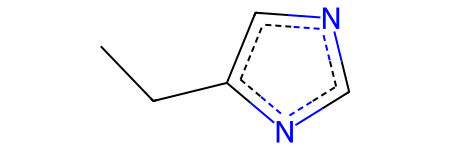

In [4]:
Chem.MolFromSmarts('C-C-c:1:n:c:n:c:1')

In [ ]:
def autodock_covalent(output_folder, receptor_dir_path, ligand_input_sdf_path, reactive_flexible_residue, nrun):

    subprocess.run(f"mkdir {output_folder}", cwd = receptor_dir_path, shell = True)
    subprocess.run(f"mk_prepare_ligand.py \
                    -i {ligand_input_sdf_path} \
                    --receptor *_clean.pdb \
                    --rec_residue {reactive_flexible_residue} \
                    --tether_smarts 'C-C-c:1:n:c:n:c:1'\
                    --tether_smarts_indices 1 2 \
                    -o {output_folder}/ligand.pdbqt", cwd = receptor_dir_path, shell = True)
                    #--multimol_prefix ligand \
                    #--multimol_outdir {output_folder}", cwd = receptor_dir_path, shell = True)
    
    subprocess.run(f"autodock_gpu_128wi \
                    -M receptor_rigid_rigid.maps.fld \
                    -F {output_folder}/ligand.pdbqt \
                    -nrun {nrun} \
                    -devnum 1", cwd = receptor_dir_path, shell = True)
    subprocess.run(f"mk_export.py {output_folder}/*.dlg -s {output_folder}/docked.sdf -k", cwd = receptor_dir_path, shell = True)

for res, pdb in [(286, '4TZ4'), (288, '5V3O'), (300, '8OJH')]:
    for i in range(58):
        autodock_covalent(
            output_folder=f"ligand_{i}_docked",
            receptor_dir_path=pdb,
            ligand_input_sdf_path=f"../cov_ligands/ligand_{i}_mcs_aligned_to_{pdb}.sdf",
            reactive_flexible_residue=f"A:HIS:{res}",
            nrun=100,
        )

[#6]1(-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])-&!@[#7]1-&@[#6]-&@[#6]2:&@[#6](-&@[#6]-&@1=&!@[#8]):&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@2


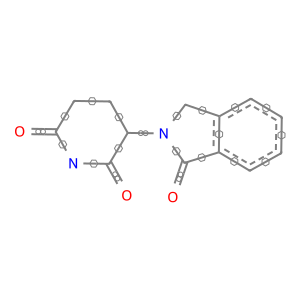

4TZ4/ligand_0_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.575892929863414
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])-&!@[#7]1-&@[#6]-&@[#6]2:&@[#6](-&@[#6]-&@1=&!@[#8]):&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@2


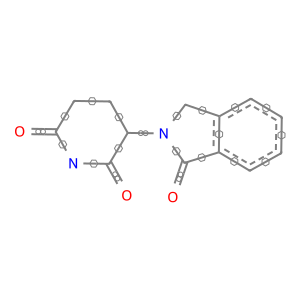

4TZ4/ligand_1_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.8798583850698805
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])-&!@[#7]1-&@[#6]-&@[#6]2:&@[#6](-&@[#6]-&@1=&!@[#8]):&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@2


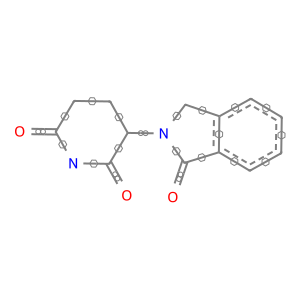

4TZ4/ligand_2_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.7986877315297274
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])-&!@[#7]1-&@[#6]-&@[#6]2:&@[#6](-&@[#6]-&@1=&!@[#8]):&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@2


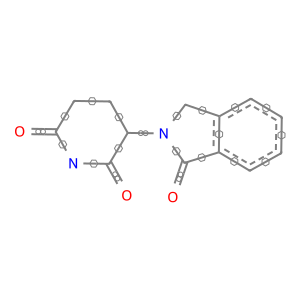

4TZ4/ligand_3_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.5635553147305739
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


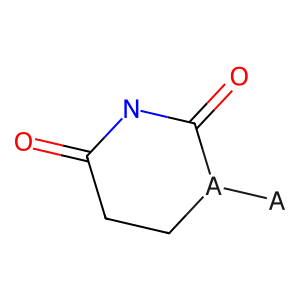

4TZ4/ligand_4_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.477493106407482
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


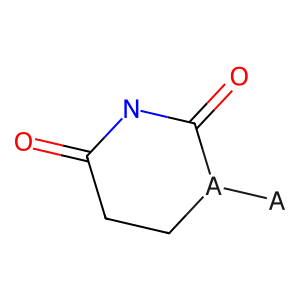

4TZ4/ligand_5_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.7173139712380722
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


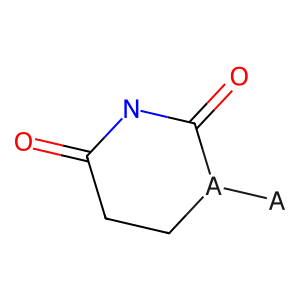

4TZ4/ligand_6_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.5529907574071901
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


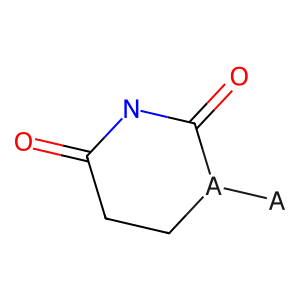

4TZ4/ligand_7_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.066208130609487
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6](:&@[#6]:&@[#6]:&@[#6]:&@1)-&!@[#7]


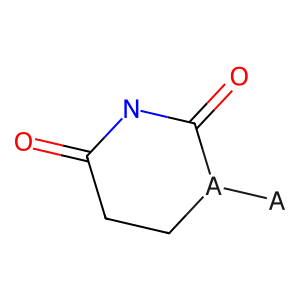

4TZ4/ligand_8_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.7887880999778496
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


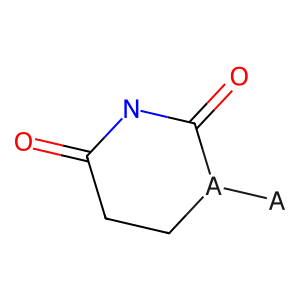

4TZ4/ligand_9_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.815774274334921
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


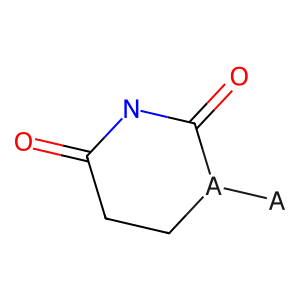

4TZ4/ligand_10_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.0515428875915827
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


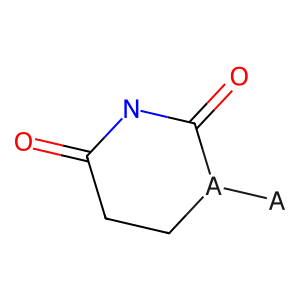

4TZ4/ligand_11_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.9508187115440166
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


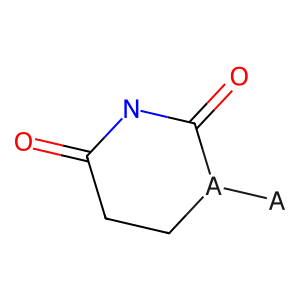

4TZ4/ligand_12_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.6942986869256393
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])-&!@[#7]1-&@[#6]-,:;@[#6]2:&@[#6](-&@[#6]-&@1=&!@[#8]):&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@2


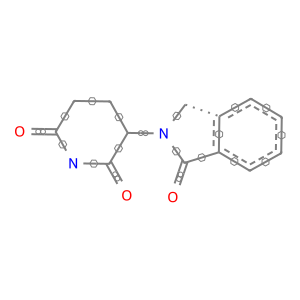

4TZ4/ligand_13_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.757963310197343
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])-&!@[#7]1-&@[#6]-,:;@[#6]2:&@[#6](-&@[#6]-&@1=&!@[#8]):&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@2


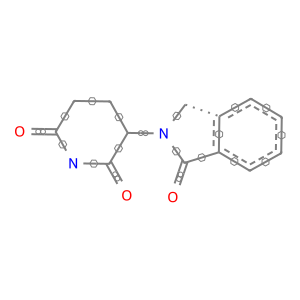

4TZ4/ligand_14_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.9427808820233836
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])-&!@[#7]1-&@[#6]-,:;@[#6]2:&@[#6](-&@[#6]-&@1=&!@[#8]):&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@2


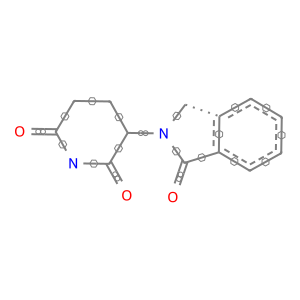

4TZ4/ligand_15_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.5001034337459045
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])-&!@[#7]1-&@[#6]-,:;@[#6]2:&@[#6](-&@[#6]-&@1=&!@[#8]):&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@2


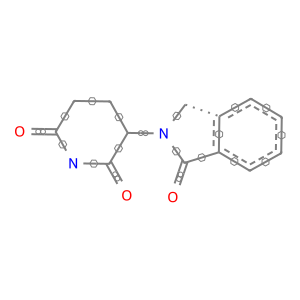

4TZ4/ligand_16_docked/docked.sdf
Best aligned conformation ID: 1 with MCS RMSD: 1.7866514924728758
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


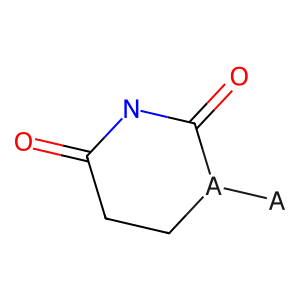

4TZ4/ligand_17_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.0921027118972522
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


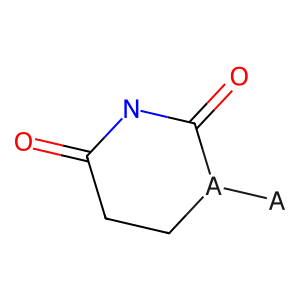

4TZ4/ligand_18_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.7615068395403065
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


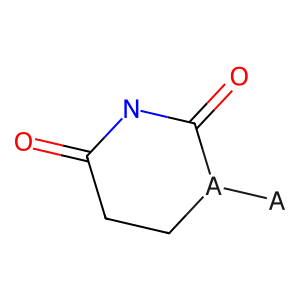

4TZ4/ligand_19_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.621638784003844
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])-&!@[#7]


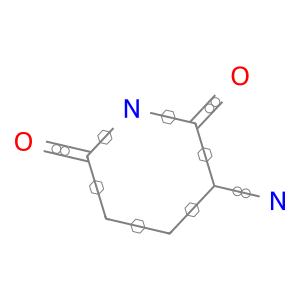

4TZ4/ligand_20_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.6952752452566296
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])-&!@[#7]


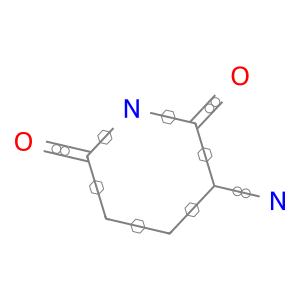

4TZ4/ligand_21_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.2948251836069791
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])-&!@[#7]


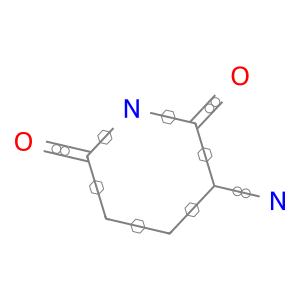

4TZ4/ligand_22_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.5642056362710322
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])-&!@[#7]


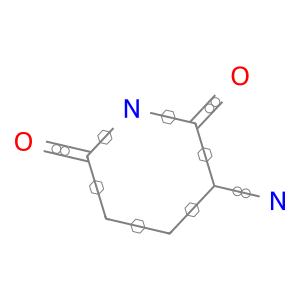

4TZ4/ligand_23_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.7788465117652442
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


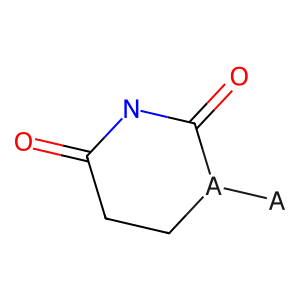

4TZ4/ligand_24_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.6569201710338253
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


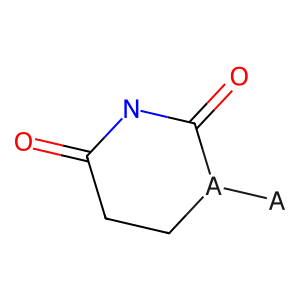

4TZ4/ligand_25_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.5933424156608237
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


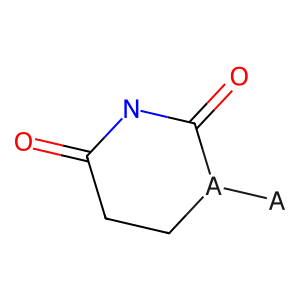

4TZ4/ligand_26_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.4846174894812516
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


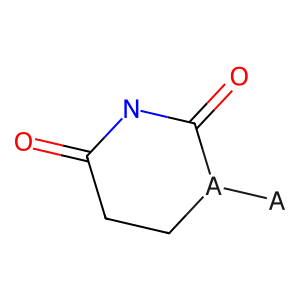

4TZ4/ligand_27_docked/docked.sdf
Best aligned conformation ID: 1 with MCS RMSD: 0.8815176307558078
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


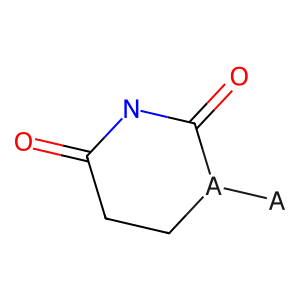

4TZ4/ligand_28_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.6633339195977304
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


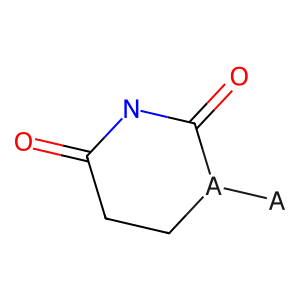

4TZ4/ligand_29_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.9867519670334814
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


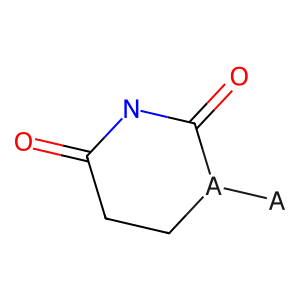

4TZ4/ligand_30_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.0476920136927435
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


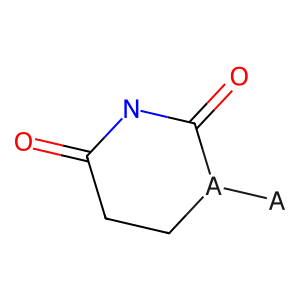

4TZ4/ligand_31_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.8036280925347942
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


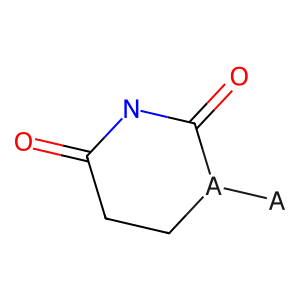

4TZ4/ligand_32_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.5062246975844275
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


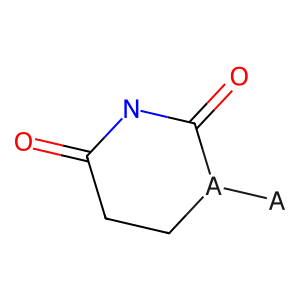

4TZ4/ligand_33_docked/docked.sdf
Best aligned conformation ID: 1 with MCS RMSD: 0.723353532744075
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6](:&@[#6]:&@[#6]:&@[#6]:&@1)-&!@[#7]


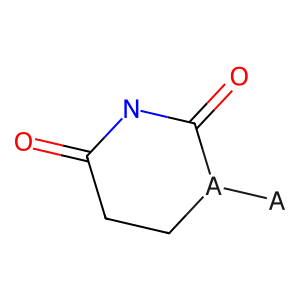

4TZ4/ligand_34_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.5563364289907884
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


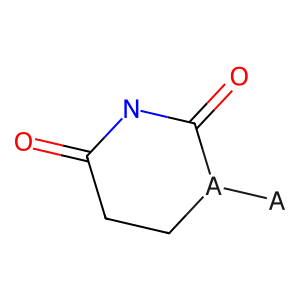

4TZ4/ligand_35_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.0419631044864834
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


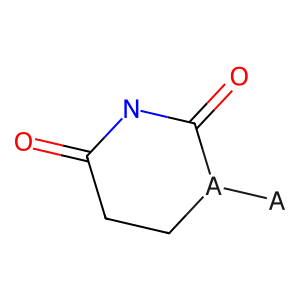

4TZ4/ligand_36_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.9545347907052241
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


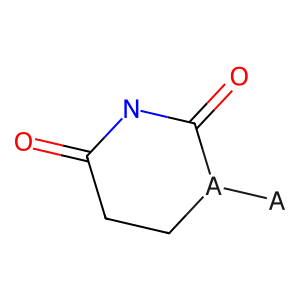

4TZ4/ligand_37_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.0673824681590631
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


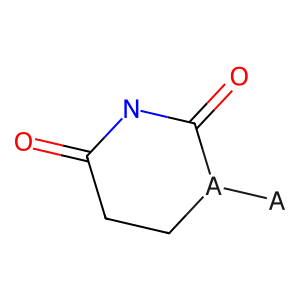

4TZ4/ligand_38_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.8231750860067509
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


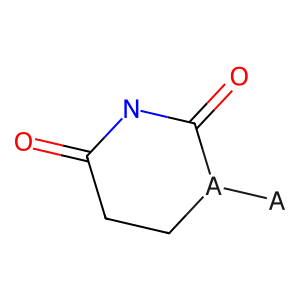

4TZ4/ligand_39_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.6117871815881369
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


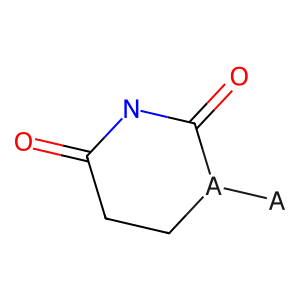

4TZ4/ligand_40_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.0615788556045507
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


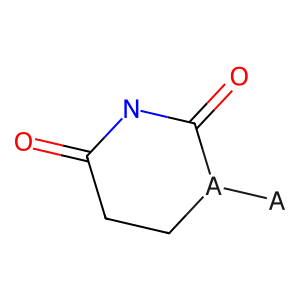

4TZ4/ligand_41_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.418516556908034
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


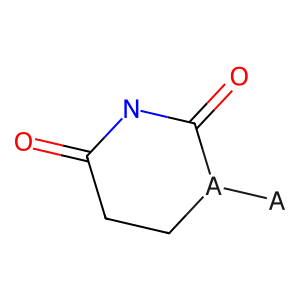

4TZ4/ligand_42_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.6362892424047413
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])-&!@[#7]


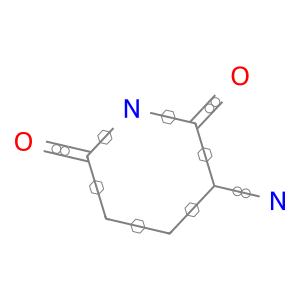

4TZ4/ligand_43_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.4443419604063715
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])-&!@[#7]


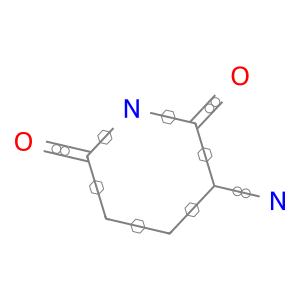

4TZ4/ligand_44_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.6548256765480934
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


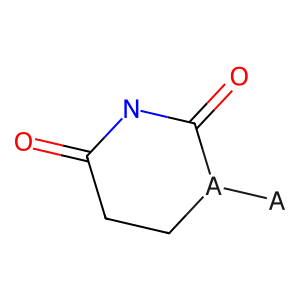

4TZ4/ligand_45_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.5991126772152298
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])-&!@[#7]


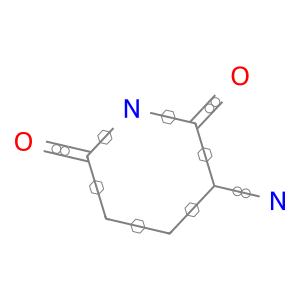

4TZ4/ligand_46_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.7437352426173653
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])-&!@[#7]


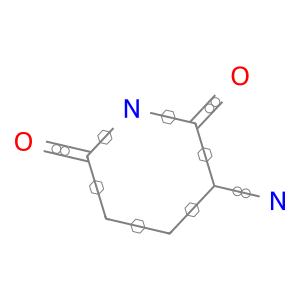

4TZ4/ligand_47_docked/docked.sdf
Best aligned conformation ID: 3 with MCS RMSD: 0.5350268944434265
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


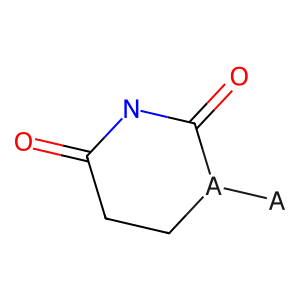

4TZ4/ligand_48_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.656383949292554
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


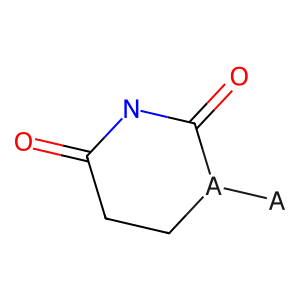

4TZ4/ligand_49_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.8036125379255298
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8])-&!@[#7]


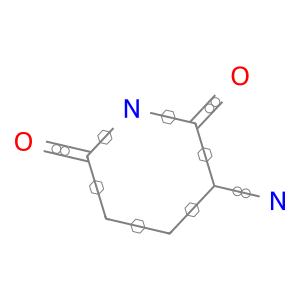

4TZ4/ligand_50_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.8890625524799823
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


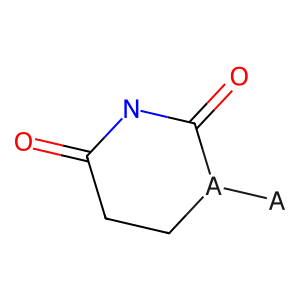

4TZ4/ligand_51_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.8474319376143956
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6](:&@[#6]:&@[#6]:&@[#6]:&@1)-&!@[#7]


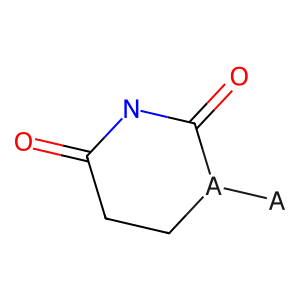

4TZ4/ligand_52_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.7191535920016594
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6](:&@[#6]:&@[#6]:&@[#6]:&@1)-&!@[#7]


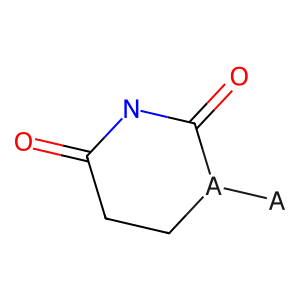

4TZ4/ligand_53_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.8593645585224267
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


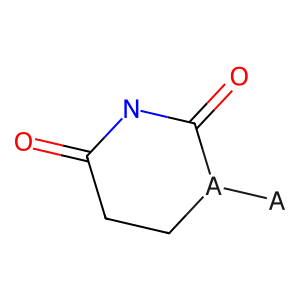

4TZ4/ligand_54_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.8455187099579105
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


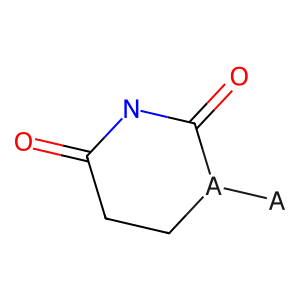

4TZ4/ligand_55_docked/docked.sdf
Best aligned conformation ID: 1 with MCS RMSD: 0.5675713366813211
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


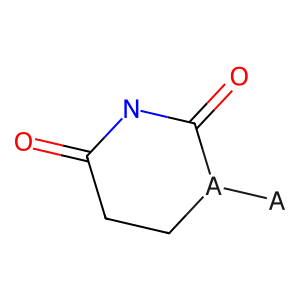

4TZ4/ligand_56_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.6062358360315637
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


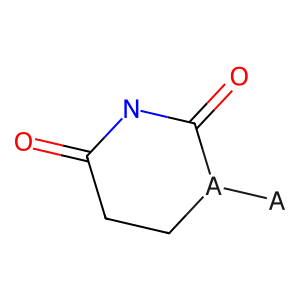

4TZ4/ligand_57_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.6067655597052659
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]2:&@[#6](:&@[#6]:&@1)-&@[#6]-&@[#7](-&@[#6]-&@2=&!@[#8])-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


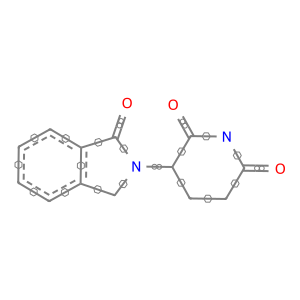

5V3O/ligand_0_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.7126233226607166
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]2:&@[#6](:&@[#6]:&@1)-&@[#6]-&@[#7](-&@[#6]-&@2=&!@[#8])-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


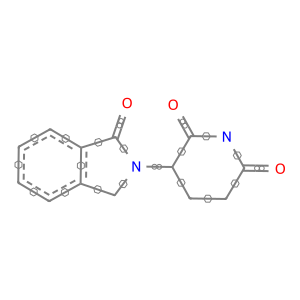

5V3O/ligand_1_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.8845974916436412
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]2:&@[#6]:&@1-&@[#6]-&@[#7](-&@[#6]-&@2=&!@[#8])-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


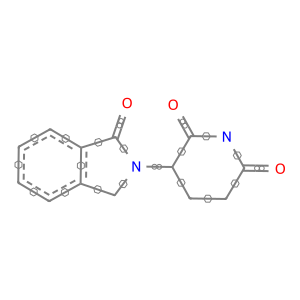

5V3O/ligand_2_docked/docked.sdf
Best aligned conformation ID: 1 with MCS RMSD: 2.3851302317110945
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]2:&@[#6]:&@1-&@[#6]-&@[#7](-&@[#6]-&@2=&!@[#8])-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


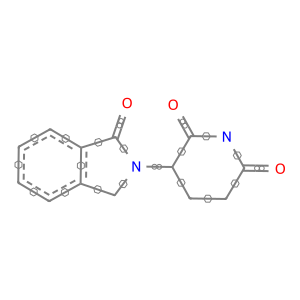

5V3O/ligand_3_docked/docked.sdf
Best aligned conformation ID: 1 with MCS RMSD: 2.1286239817204806
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


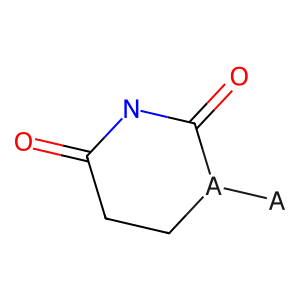

5V3O/ligand_4_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.771477946685595
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


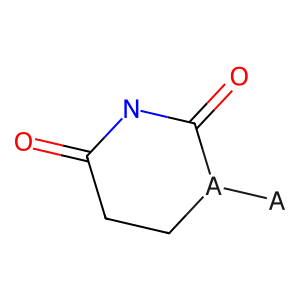

5V3O/ligand_5_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.029774031307624
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6](-&!@[#8]-&!@[#6]):&@[#6]:&@[#6]:&@[#6]:&@1


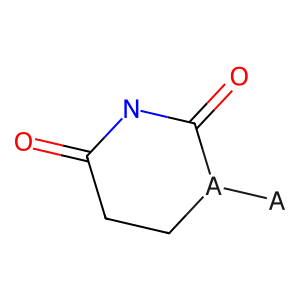

5V3O/ligand_6_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.5060519297024317
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6](-&!@[#8]-&!@[#6]):&@[#6]:&@[#6]:&@[#6]:&@1


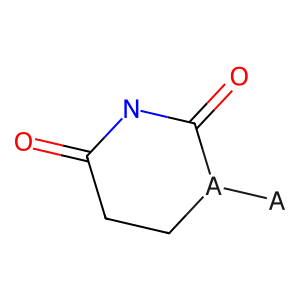

5V3O/ligand_7_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.0721712653406734
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


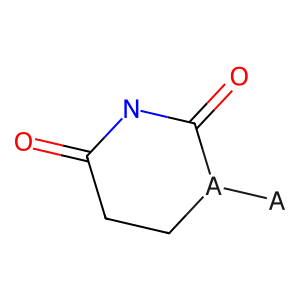

5V3O/ligand_8_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.9788804830008617
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6](:&@[#6]:&@1)-&!@[#8]-&!@[#6]


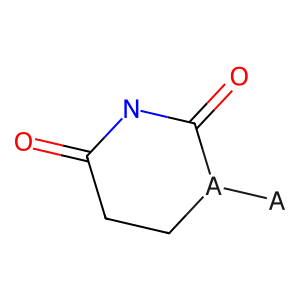

5V3O/ligand_9_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.9828134218773273
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6](:&@[#6]:&@1)-&!@[#8]-&!@[#6]


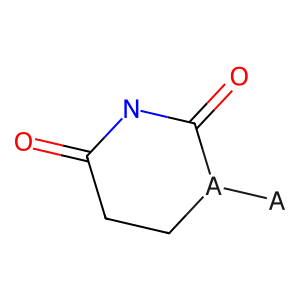

5V3O/ligand_10_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.7891397063641756
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6](:&@[#6]:&@1)-&!@[#8]-&!@[#6]


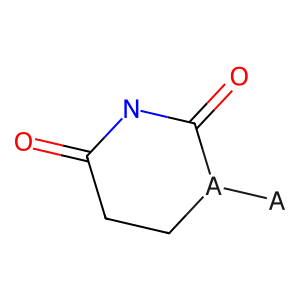

5V3O/ligand_11_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.0997044552464488
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6](:&@[#6]:&@1)-&!@[#8]-&!@[#6]


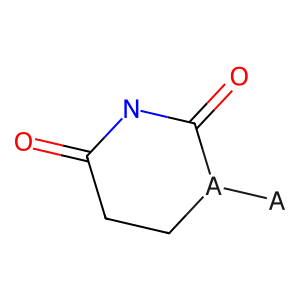

5V3O/ligand_12_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.5530341560679396
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]2:&@[#6](:&@[#6]:&@[#6]:&@1):,-;@[#6]-&@[#7](-&@[#6]-&@2=&!@[#8])-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


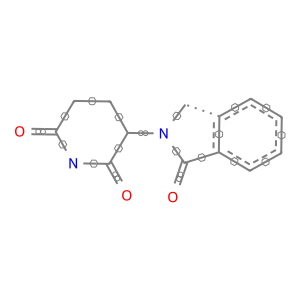

5V3O/ligand_13_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.750548207053425
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]2:&@[#6](:&@[#6]:&@[#6]:&@1):,-;@[#6]-&@[#7](-&@[#6]-&@2=&!@[#8])-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


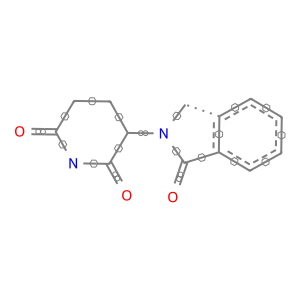

5V3O/ligand_14_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.9625474233477491
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]2:&@[#6](:&@[#6]:&@[#6]:&@1):,-;@[#6]-&@[#7](-&@[#6]-&@2=&!@[#8])-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


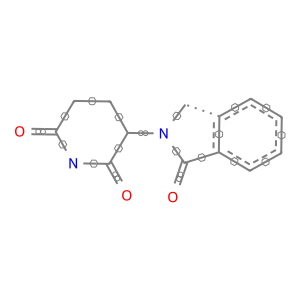

5V3O/ligand_15_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.2631153105896094
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]2:&@[#6](:&@[#6]:&@[#6]:&@1):,-;@[#6]-&@[#7](-&@[#6]-&@2=&!@[#8])-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


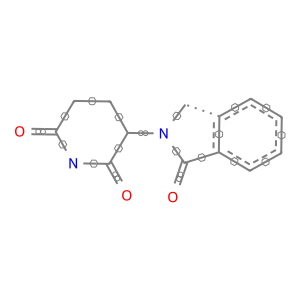

5V3O/ligand_16_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.9715035717272573
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


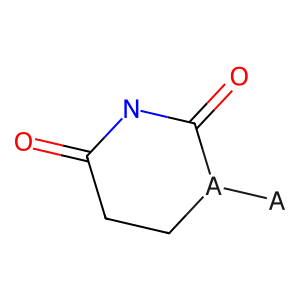

5V3O/ligand_17_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.4084354598079554
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


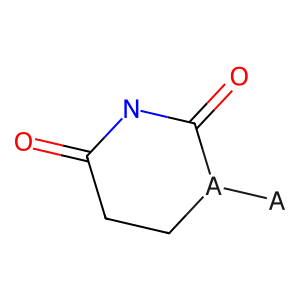

5V3O/ligand_18_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.9179736742775727
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


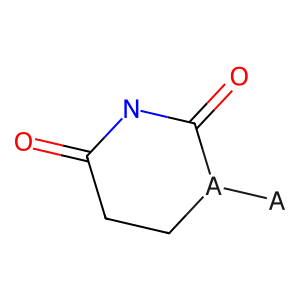

5V3O/ligand_19_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.743805604830844
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


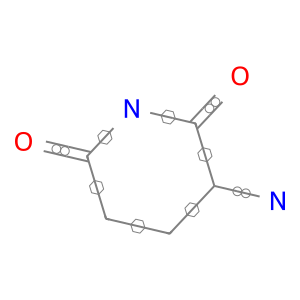

5V3O/ligand_20_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.6980033428764268
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


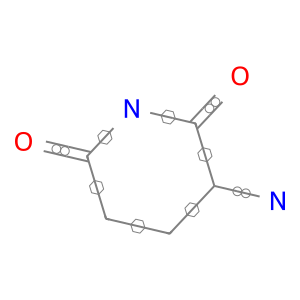

5V3O/ligand_21_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.6149132730176943
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


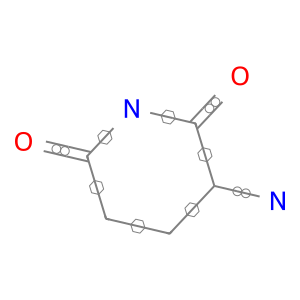

5V3O/ligand_22_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.47819905199961815
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


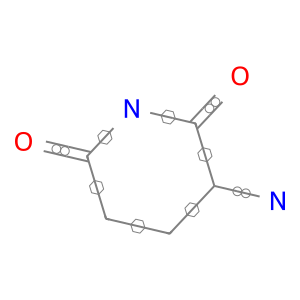

5V3O/ligand_23_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.6776910964607857
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6](-&!@[#8]-&!@[#6]):&@[#6]:&@[#6]:&@[#6]:&@1


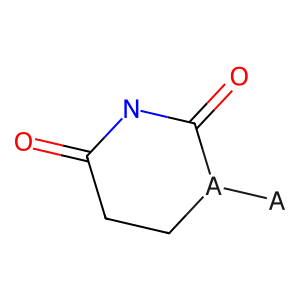

5V3O/ligand_24_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.6094714467835585
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6](-&!@[#8]-&!@[#6]):&@[#6]:&@[#6]:&@[#6]:&@1


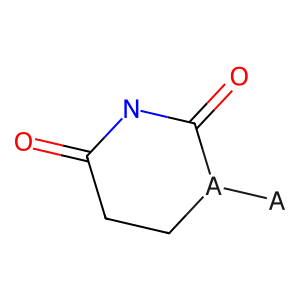

5V3O/ligand_25_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.568612639090386
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6](:&@[#6]:&@1)-&!@[#8]-&!@[#6]


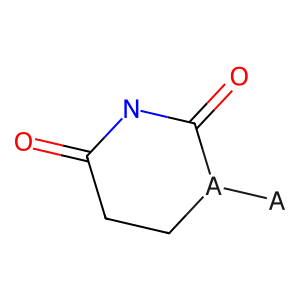

5V3O/ligand_26_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.5528911888126513
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6](:&@[#6]:&@1)-&!@[#8]-&!@[#6]


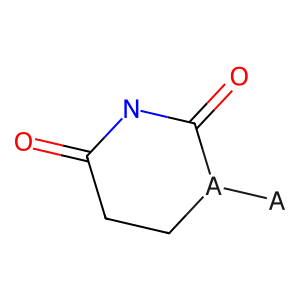

5V3O/ligand_27_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.0562020008817754
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6](-&!@[#8]-&!@[#6]):&@[#6]:&@[#6]:&@[#6]:&@1


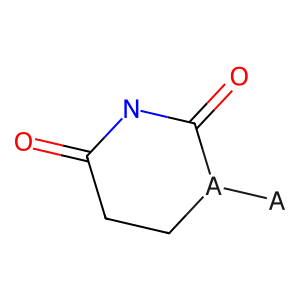

5V3O/ligand_28_docked/docked.sdf
Best aligned conformation ID: 1 with MCS RMSD: 0.5244928767655258
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6](-&!@[#8]-&!@[#6]):&@[#6]:&@[#6]:&@[#6]:&@1


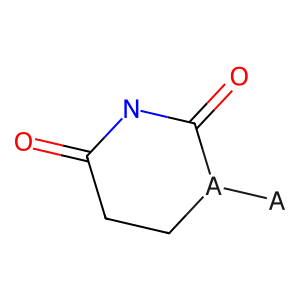

5V3O/ligand_29_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.9813260869297669
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6](-&!@[#8]-&!@[#6]):&@[#6]:&@[#6]:&@[#6]:&@1


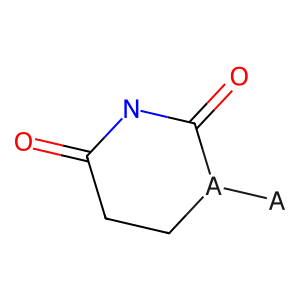

5V3O/ligand_30_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.83583005749443
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6](-&!@[#8]-&!@[#6]):&@[#6]:&@[#6]:&@[#6]:&@1


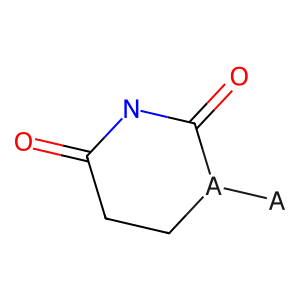

5V3O/ligand_31_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.8757726112791303
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


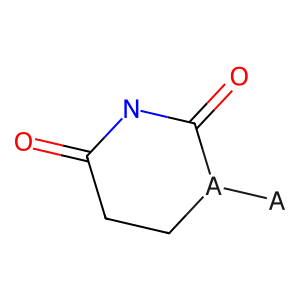

5V3O/ligand_32_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.5468052669826804
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


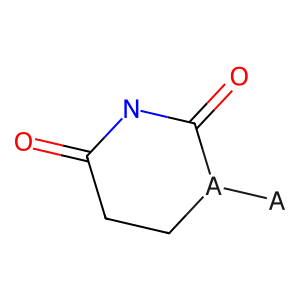

5V3O/ligand_33_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.711380426432377
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


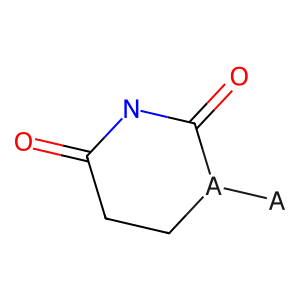

5V3O/ligand_34_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.5295791830416967
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6](-&!@[#8]-&!@[#6]):&@[#6]:&@[#6]:&@[#6]:&@1


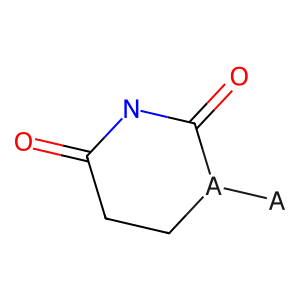

5V3O/ligand_35_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.5405675361156141
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6](-&!@[#8]-&!@[#6]):&@[#6]:&@[#6]:&@[#6]:&@1


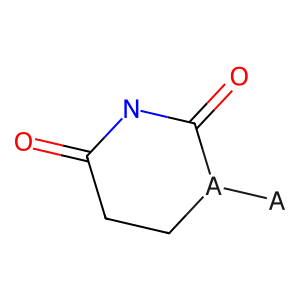

5V3O/ligand_36_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.0577300117599844
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6](:&@[#6]:&@1)-&!@[#8]-&!@[#6]


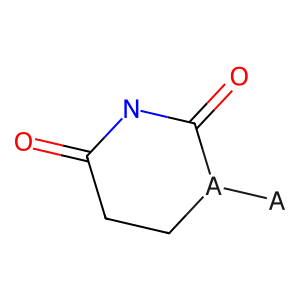

5V3O/ligand_37_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.7983037377855091
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6](:&@[#6]:&@1)-&!@[#8]-&!@[#6]


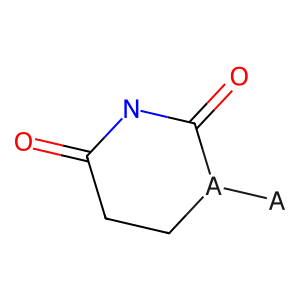

5V3O/ligand_38_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.9882104476724014
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6](-&!@[#8]-&!@[#6]):&@[#6]:&@[#6]:&@[#6]:&@1


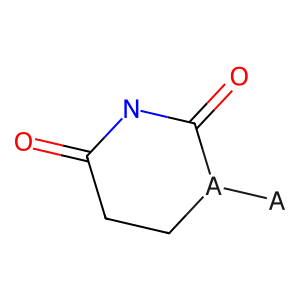

5V3O/ligand_39_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.5927284369759896
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6](-&!@[#8]-&!@[#6]):&@[#6]:&@[#6]:&@[#6]:&@1


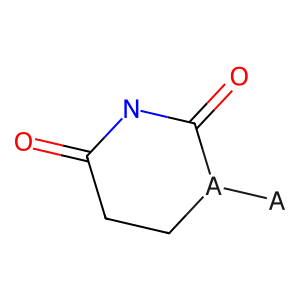

5V3O/ligand_40_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.0473566197283941
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


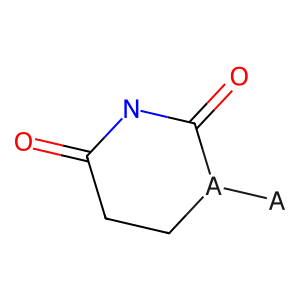

5V3O/ligand_41_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.3046728410686808
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


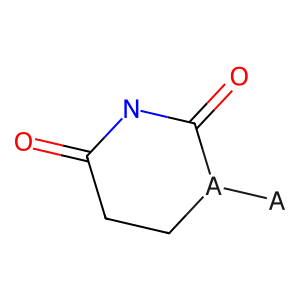

5V3O/ligand_42_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.6450739836983386
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


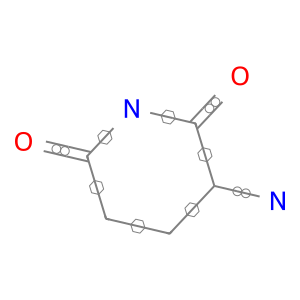

5V3O/ligand_43_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.7233775716118878
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


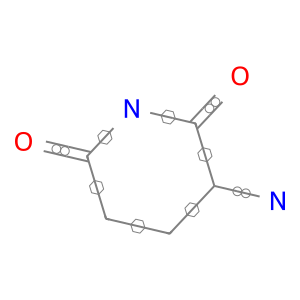

5V3O/ligand_44_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.6484933821302012
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


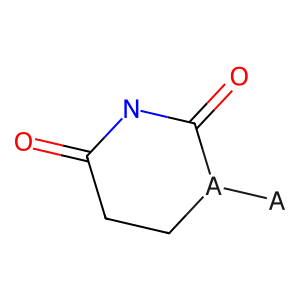

5V3O/ligand_45_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.5354146887122994
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


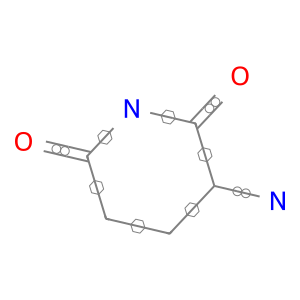

5V3O/ligand_46_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.7290137934985256
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


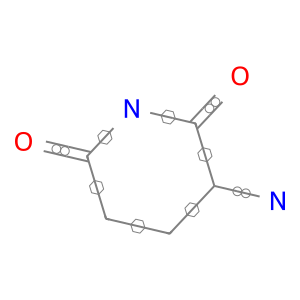

5V3O/ligand_47_docked/docked.sdf
Best aligned conformation ID: 1 with MCS RMSD: 0.4902461966536133
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6](-&!@[#6]):&@[#6]:&@[#6]:&@[#6]:&@1-&!@[#6]


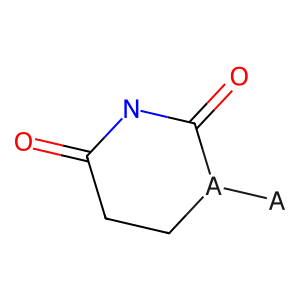

5V3O/ligand_48_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.7727660994404741
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6](-&!@[#6]):&@[#6]:&@[#6]:&@[#6]:&@1-&!@[#6]


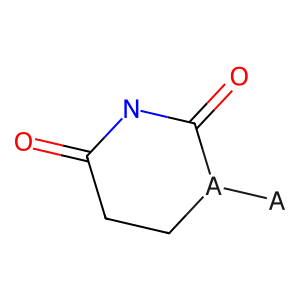

5V3O/ligand_49_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.1191838296028251
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1(-&!@[#7])-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


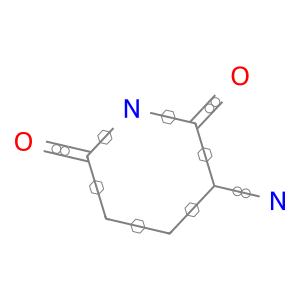

5V3O/ligand_50_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.293823790166188
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


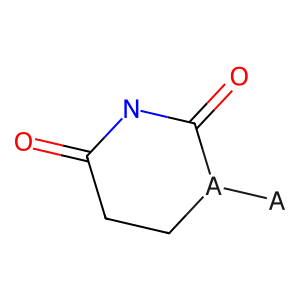

5V3O/ligand_51_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 2.4499668251722198
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


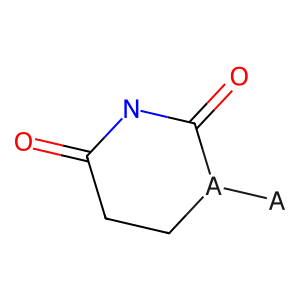

5V3O/ligand_52_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.9205824243379844
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


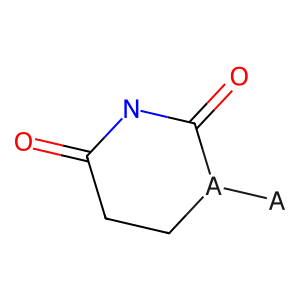

5V3O/ligand_53_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.9523879928311195
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6](-&!@[#8]-&!@[#6]):&@[#6]:&@[#6]:&@[#6]:&@1


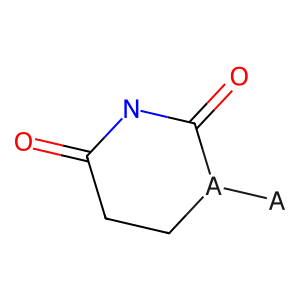

5V3O/ligand_54_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.9880619638688881
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6](-&!@[#8]-&!@[#6]):&@[#6]:&@[#6]:&@[#6]:&@1


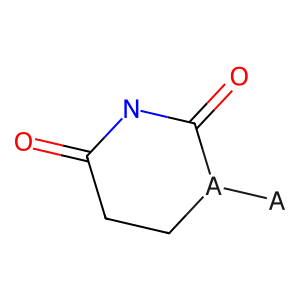

5V3O/ligand_55_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.517418163148101
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


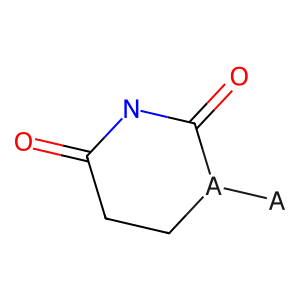

5V3O/ligand_56_docked/docked.sdf
Best aligned conformation ID: 1 with MCS RMSD: 0.5558589949098801
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


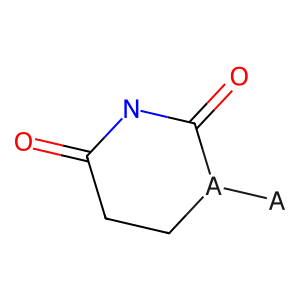

5V3O/ligand_57_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.6151247389306044
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]2:&@[#6](:&@[#6]:&@[#6]:&@[#6]:&@1)-&@[#6]-&@[#7](-&@[#6]-&@2=&!@[#8])-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


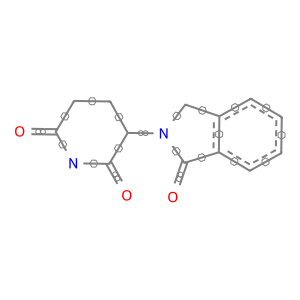

8OJH/ligand_0_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.8850657226067076
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]2:&@[#6](:&@[#6]:&@[#6]:&@[#6]:&@1)-&@[#6]-&@[#7](-&@[#6]-&@2=&!@[#8])-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


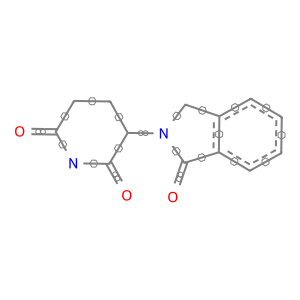

8OJH/ligand_1_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.0143804074956844
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]2:&@[#6](:&@[#6]:&@[#6]:&@[#6]:&@1)-&@[#6]-&@[#7](-&@[#6]-&@2=&!@[#8])-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


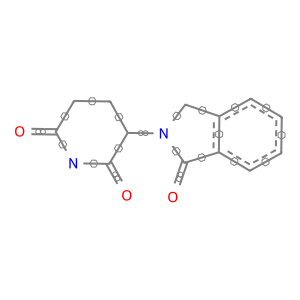

8OJH/ligand_2_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 2.205616114477867
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]2:&@[#6](:&@[#6]:&@[#6]:&@[#6]:&@1)-&@[#6]-&@[#7](-&@[#6]-&@2=&!@[#8])-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


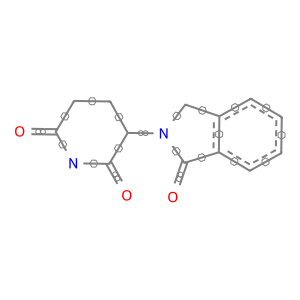

8OJH/ligand_3_docked/docked.sdf
Best aligned conformation ID: 1 with MCS RMSD: 1.8824680313059472
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6]-&@[#6]-&@1=&!@[#8]


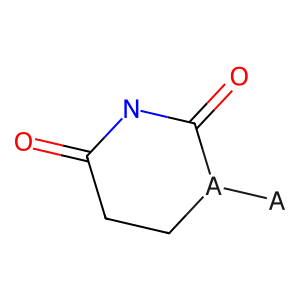

8OJH/ligand_4_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.40455833256088614
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6]-&@[#6]-&@1=&!@[#8]


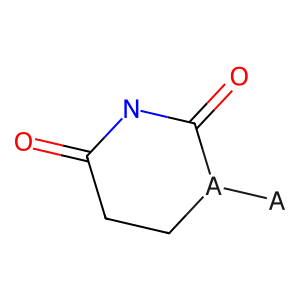

8OJH/ligand_5_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.7071293296766076
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


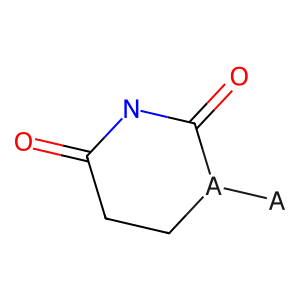

8OJH/ligand_6_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.6010783827607036
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


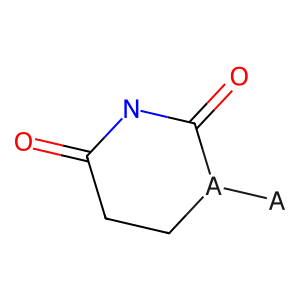

8OJH/ligand_7_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.8445612273048455
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6](:&@[#6]:&@[#6]:&@1)-&!@[#7]


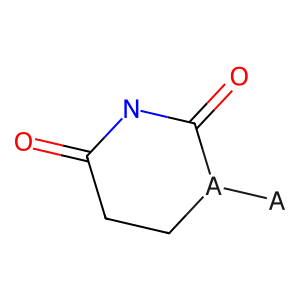

8OJH/ligand_8_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.5201061857394547
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


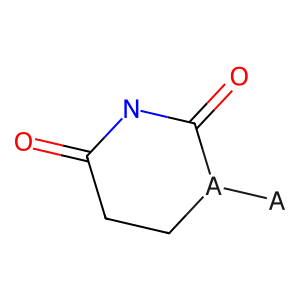

8OJH/ligand_9_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.8100447175585088
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


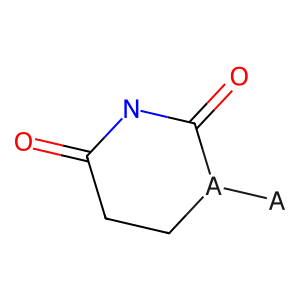

8OJH/ligand_10_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 2.425043688037164
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


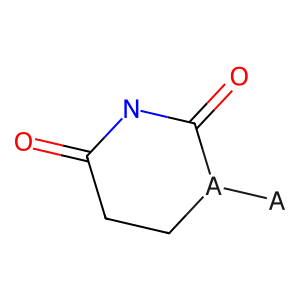

8OJH/ligand_11_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.6151942782568768
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


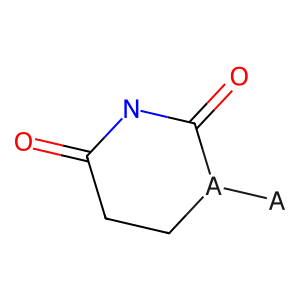

8OJH/ligand_12_docked/docked.sdf
Best aligned conformation ID: 1 with MCS RMSD: 0.7239274058142081
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]2:&@[#6](:&@[#6]:&@[#6]:&@[#6]:&@1)-,:;@[#6]-&@[#7](-&@[#6]-&@2=&!@[#8])-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


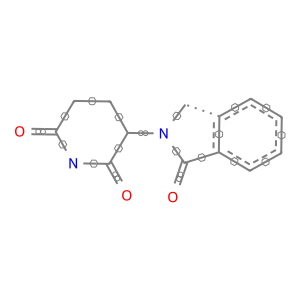

8OJH/ligand_13_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.8182562922878736
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]2:&@[#6](:&@[#6]:&@[#6]:&@[#6]:&@1)-,:;@[#6]-&@[#7](-&@[#6]-&@2=&!@[#8])-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


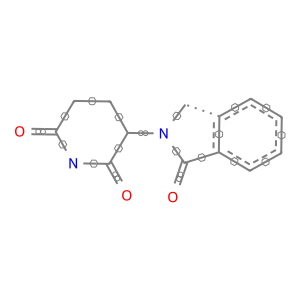

8OJH/ligand_14_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.9560898496745995
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]2:&@[#6](:&@[#6]:&@[#6]:&@[#6]:&@1)-,:;@[#6]-&@[#7](-&@[#6]-&@2=&!@[#8])-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


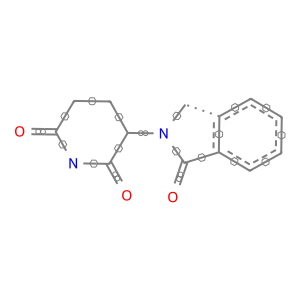

8OJH/ligand_15_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.28736881064815195
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]2:&@[#6](:&@[#6]:&@[#6]:&@[#6]:&@1)-,:;@[#6]-&@[#7](-&@[#6]-&@2=&!@[#8])-&!@[#6]1-&@[#6]-&@[#6]-&@[#6](-&@[#7]-&@[#6]-&@1=&!@[#8])=&!@[#8]


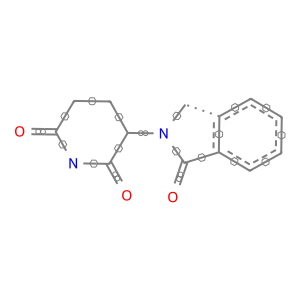

8OJH/ligand_16_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.9703002168310402
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6]-&@[#6]-&@1=&!@[#8]


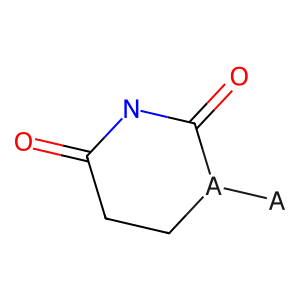

8OJH/ligand_17_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.3309714914719657
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6]-&@[#6]-&@1=&!@[#8]


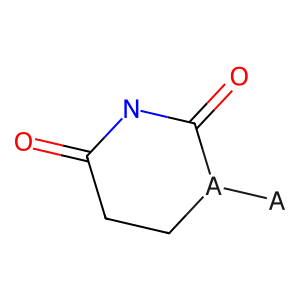

8OJH/ligand_18_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.7774269526242749
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


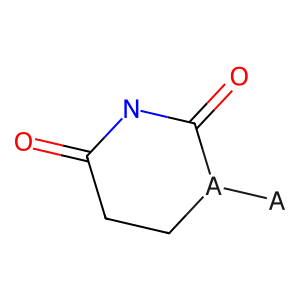

8OJH/ligand_19_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.47433626141049834
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6](-&@[#6]-&@1=&!@[#8])-&!@[#7]


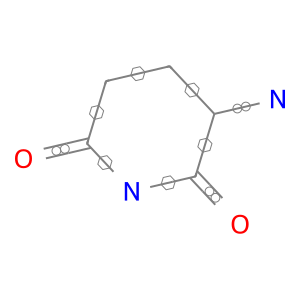

8OJH/ligand_20_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.7199085590082487
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6](-&@[#6]-&@1=&!@[#8])-&!@[#7]


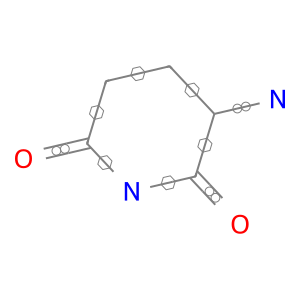

8OJH/ligand_21_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.5535797644021647
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6](-&@[#6]-&@1=&!@[#8])-&!@[#7]


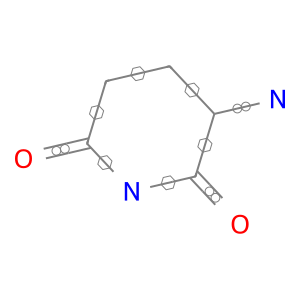

8OJH/ligand_22_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.5136951106119924
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6](-&@[#6]-&@1=&!@[#8])-&!@[#7]


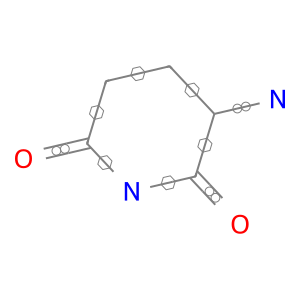

8OJH/ligand_23_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.5005952012909786
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


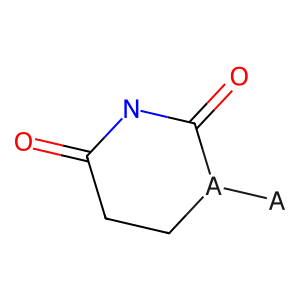

8OJH/ligand_24_docked/docked.sdf
Best aligned conformation ID: 1 with MCS RMSD: 0.6571234451929278
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


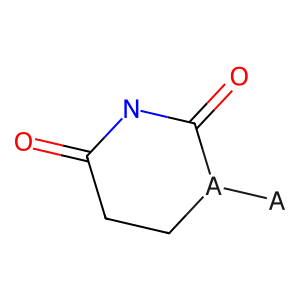

8OJH/ligand_25_docked/docked.sdf
Best aligned conformation ID: 1 with MCS RMSD: 0.6560124490688674
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


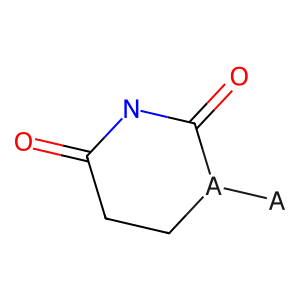

8OJH/ligand_26_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.6967677757569827
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


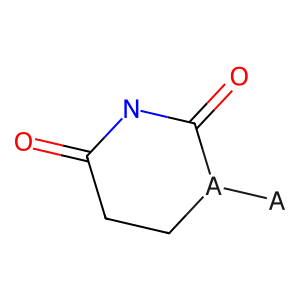

8OJH/ligand_27_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.033281181479659
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


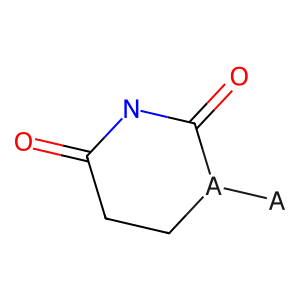

8OJH/ligand_28_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.7552365339562321
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


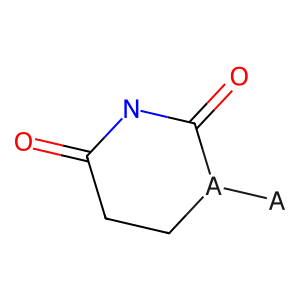

8OJH/ligand_29_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.1185348551664456
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


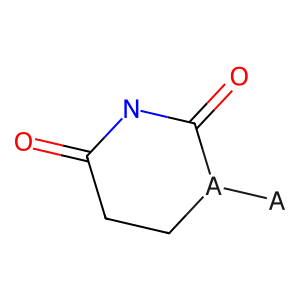

8OJH/ligand_30_docked/docked.sdf
Best aligned conformation ID: 1 with MCS RMSD: 1.633343775476825
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


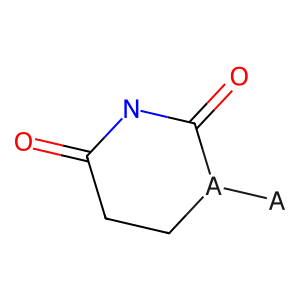

8OJH/ligand_31_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.6765108194913731
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6]-&@[#6]-&@1=&!@[#8]


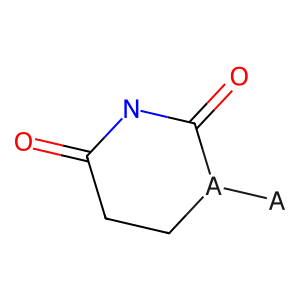

8OJH/ligand_32_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.394914618057569
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6]-&@[#6]-&@1=&!@[#8]


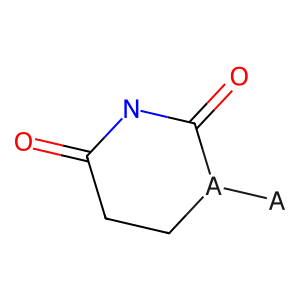

8OJH/ligand_33_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.6585729521725997
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6](:&@[#6]:&@[#6]:&@1)-&!@[#7]


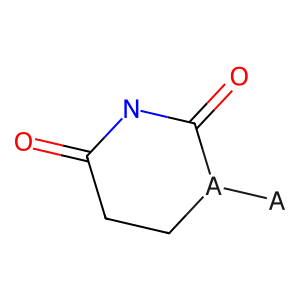

8OJH/ligand_34_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.33363003461918733
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


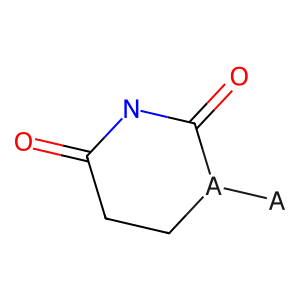

8OJH/ligand_35_docked/docked.sdf
Best aligned conformation ID: 1 with MCS RMSD: 1.4969811473614338
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


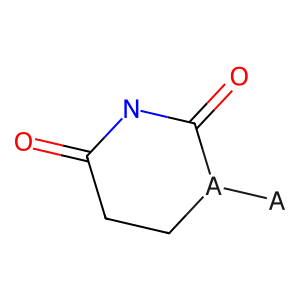

8OJH/ligand_36_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.9955026647656736
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


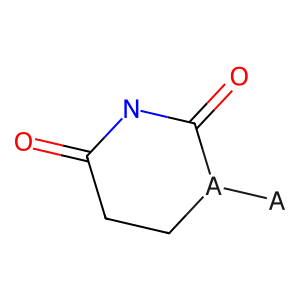

8OJH/ligand_37_docked/docked.sdf
Best aligned conformation ID: 1 with MCS RMSD: 1.6288272195389888
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


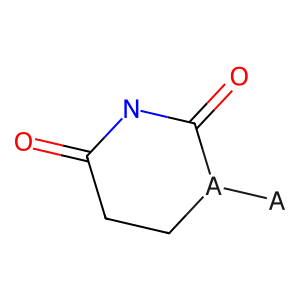

8OJH/ligand_38_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.6524507644259456
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


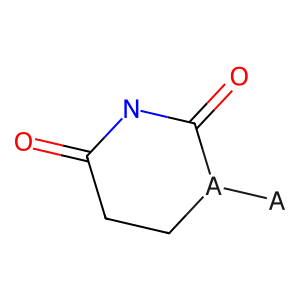

8OJH/ligand_39_docked/docked.sdf
Best aligned conformation ID: 1 with MCS RMSD: 0.5644631667936064
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


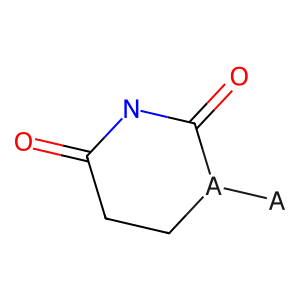

8OJH/ligand_40_docked/docked.sdf
Best aligned conformation ID: 1 with MCS RMSD: 0.6720029761838857
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6]-&@[#6]-&@1=&!@[#8]


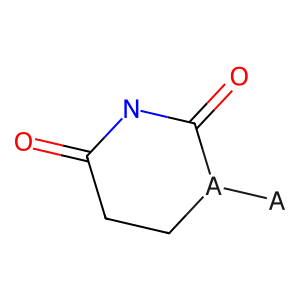

8OJH/ligand_41_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.4667545428219708
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6]-&@[#6]-&@1=&!@[#8]


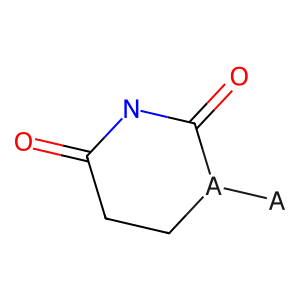

8OJH/ligand_42_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.6027899025918296
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6](-&@[#6]-&@1=&!@[#8])-&!@[#7]


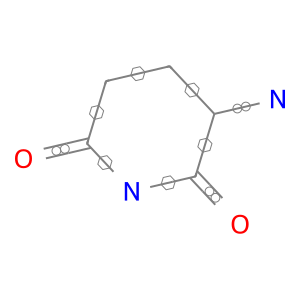

8OJH/ligand_43_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.44584638610176114
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6](-&@[#6]-&@1=&!@[#8])-&!@[#7]


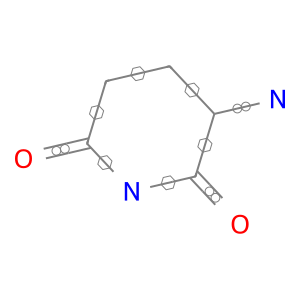

8OJH/ligand_44_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.6804945913737218
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


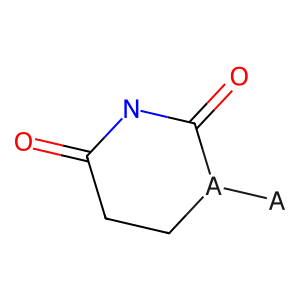

8OJH/ligand_45_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.5422098814624788
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6](-&@[#6]-&@1=&!@[#8])-&!@[#7]


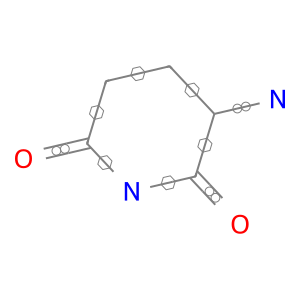

8OJH/ligand_46_docked/docked.sdf
Best aligned conformation ID: 1 with MCS RMSD: 0.47152058986503087
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6](-&@[#6]-&@1=&!@[#8])-&!@[#7]


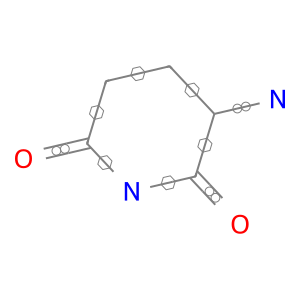

8OJH/ligand_47_docked/docked.sdf
Best aligned conformation ID: 1 with MCS RMSD: 0.635100516978743
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6]-&@[#6]-&@1=&!@[#8]


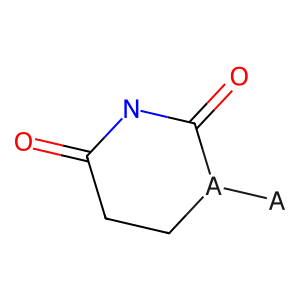

8OJH/ligand_48_docked/docked.sdf
Best aligned conformation ID: 1 with MCS RMSD: 1.064368252898299
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6]-&@[#6]-&@1=&!@[#8]


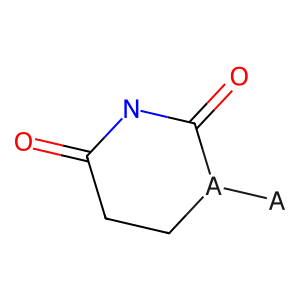

8OJH/ligand_49_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.1112840920904665
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6](-&@[#6]-&@1=&!@[#8])-&!@[#7]


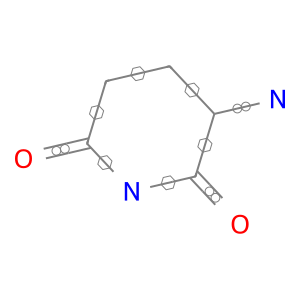

8OJH/ligand_50_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.8958872076823565
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6]-&@[#6]-&@1=&!@[#8]


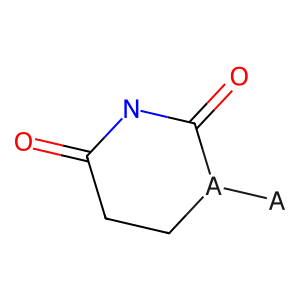

8OJH/ligand_51_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.832423102888322
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


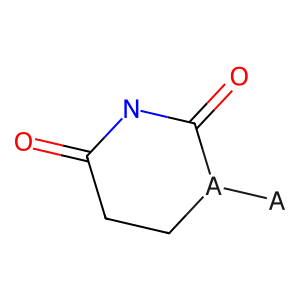

8OJH/ligand_52_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.8871508076733935
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


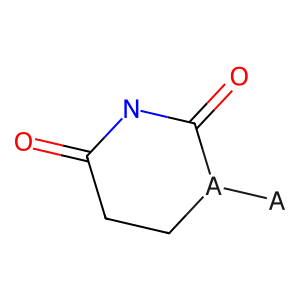

8OJH/ligand_53_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 1.098034759619809
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


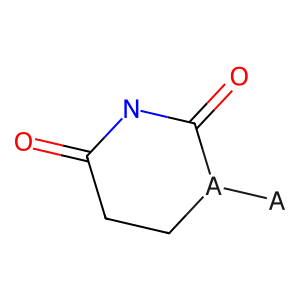

8OJH/ligand_54_docked/docked.sdf
Best aligned conformation ID: 1 with MCS RMSD: 0.4827074108033192
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#6]-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


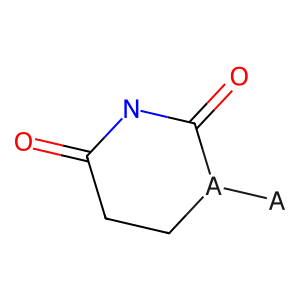

8OJH/ligand_55_docked/docked.sdf
Best aligned conformation ID: 2 with MCS RMSD: 0.4799318238620525
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6]-&@[#6]-&@1=&!@[#8]


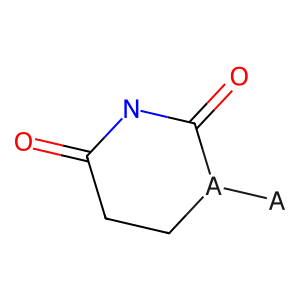

8OJH/ligand_56_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.4108071999801799
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[#7]1-&@[#6](=&!@[#8])-&@[#6]-&@[#6]-&@[#6]-&@[#6]-&@1=&!@[#8]


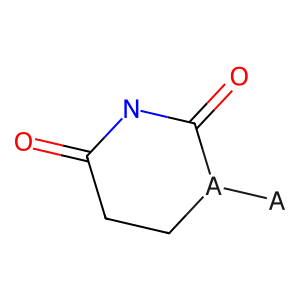

8OJH/ligand_57_docked/docked.sdf
Best aligned conformation ID: 0 with MCS RMSD: 0.6312132937622772
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


In [4]:
#conda vina env

for pdb in ['4TZ4', '5V3O', '8OJH']:
    for i in range(58):
        get_mcs_rmsd(
            query_sdf_path=f"{pdb}/ligand_{i}_docked/docked.sdf",
            ref_sdf_path=f"{pdb}/{pdb}_ligand_ob_H.sdf",
            aligned_sdf_path=f"{pdb}/ligand_{i}_docked/docked_filtered.sdf",
            aligned=False,
        )